# Глубокий анализ

In [1]:
import os
import sys

# Указание Директории
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')

# Добавление корня проекта в sys.path (cwd уже переключён на корень)
sys.path.append(os.getcwd())
from src.price_factors import correlation_with_price, plot_price_vs_factor
from src.regression import fit_price_model, plot_predictions

import pandas as pd
from pathlib import Path

PROJECT_ROOT = Path(os.getcwd())
PROCESSED_DIR = PROJECT_ROOT / 'data' / 'processed'

df_rentals = pd.read_csv(PROCESSED_DIR / 'clean_rentals.csv')
df_secondary = pd.read_csv(PROCESSED_DIR / 'clean_secondary_market.csv')
df_new_builds = pd.read_csv(PROCESSED_DIR / 'clean_new_builds.csv')

print(f"Аренда: {len(df_rentals):,} | Вторичка: {len(df_secondary):,} | Новостройки: {len(df_new_builds):,}")

Аренда: 20,000 | Вторичка: 50,000 | Новостройки: 8,000


## 8.1 Ценообразование и факторы влияния

Разбираемся, что сильнее всего определяет цену: расстояние до метро и до центра, регрессионная модель прогноза цены за м², а также какие признаки в принципе отличают премиум-сегмент от обычного жилья.

## 8.1.1 Корреляция цены с расстоянием до метро и до центра

Считаем сразу две меры связи:

- **Пирсон** — сила *линейной* связи: насколько хорошо зависимость описывается прямой линией
- **Спирмен** — сила *монотонной* связи: работает по рангам, поэтому не ломается от выбросов и ловит зависимость, даже если она изогнутая

Значение от −1 до +1: знак — направление связи, модуль — сила. 0 — связи нет.

Премиум-сегмент и Новая Москва пока исключены, как и в разделе 7.

In [2]:
factors = ['metro_distance_min', 'to_center_km']

for label, df, price_col in [
    ('Аренда', df_rentals, 'rent_per_sqm'),
    ('Вторичка', df_secondary, 'price_per_sqm'),
    ('Новостройки', df_new_builds, 'price_per_sqm'),
]:
    print(f"\n=== {label} ===")
    print(correlation_with_price(df, price_col, factors).to_string())


=== Аренда ===
                    Пирсон  Спирмен  Объектов
metro_distance_min  -0.449    -0.50   15563.0
to_center_km        -0.448    -0.45   15563.0

=== Вторичка ===
                    Пирсон  Спирмен  Объектов
metro_distance_min  -0.490   -0.546   38807.0
to_center_km        -0.513   -0.521   38807.0

=== Новостройки ===
                    Пирсон  Спирмен  Объектов
metro_distance_min  -0.356   -0.402    6062.0
to_center_km        -0.436   -0.413    6062.0


### Проверка: а что если не исключать Новую Москву?

Новая Москва одновременно и самая дальняя от центра, и самая дешёвая — то есть она может искусственно раздувать корреляцию с расстоянием. Проверим, насколько сильно.

In [3]:
for label, df, price_col in [
    ('Аренда', df_rentals, 'rent_per_sqm'),
    ('Вторичка', df_secondary, 'price_per_sqm'),
]:
    print(f"\n=== {label}, вместе с Новой Москвой ===")
    print(correlation_with_price(df, price_col, factors, exclude_new_moscow=False).to_string())


=== Аренда, вместе с Новой Москвой ===
                    Пирсон  Спирмен  Объектов
metro_distance_min  -0.643   -0.678   18972.0
to_center_km        -0.644   -0.667   18972.0

=== Вторичка, вместе с Новой Москвой ===
                    Пирсон  Спирмен  Объектов
metro_distance_min  -0.633   -0.708   47285.0
to_center_km        -0.641   -0.713   47285.0


### Графики: цена от расстояния до метро

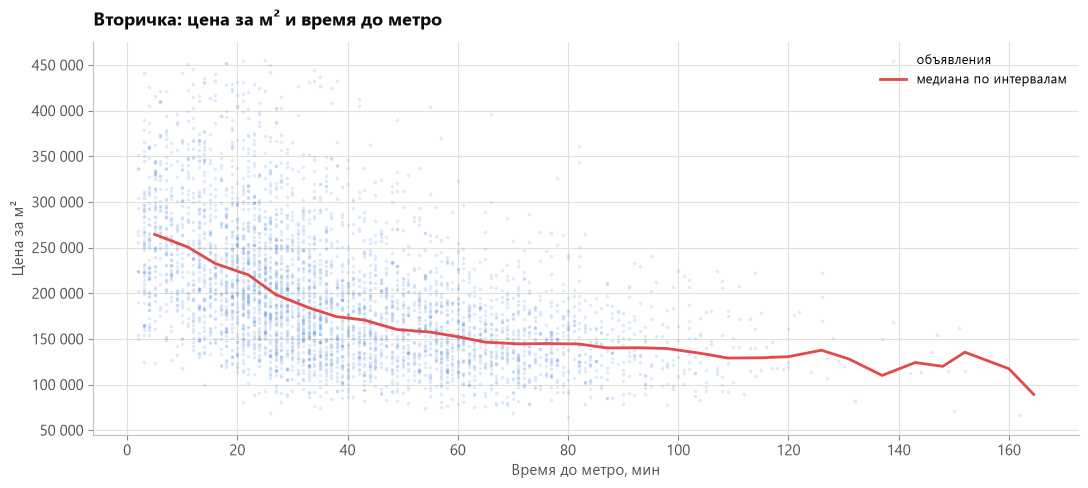

In [4]:
_ = plot_price_vs_factor(
    df_secondary, 'price_per_sqm', 'metro_distance_min',
    title='Вторичка: цена за м² и время до метро',
    xlabel='Время до метро, мин',
)

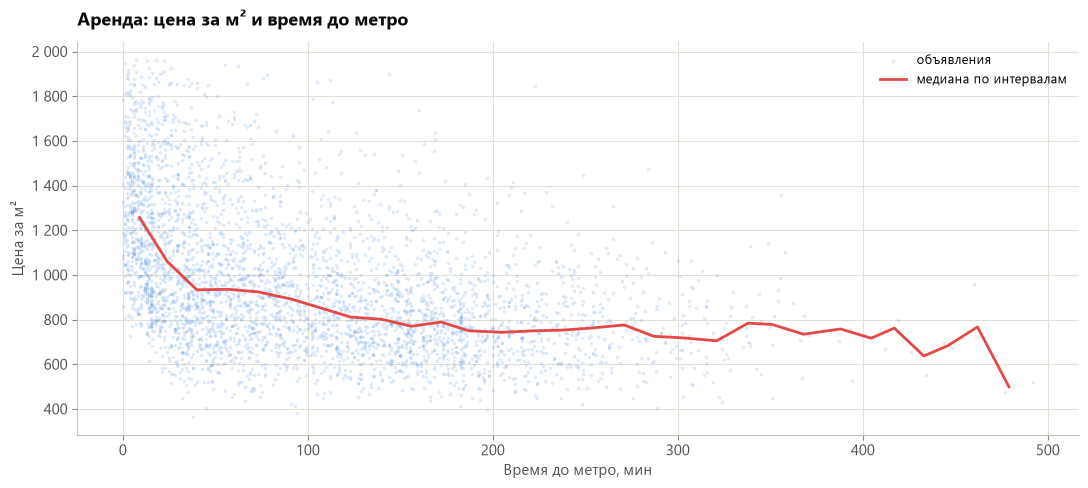

In [5]:
_ = plot_price_vs_factor(
    df_rentals, 'rent_per_sqm', 'metro_distance_min',
    title='Аренда: цена за м² и время до метро',
    xlabel='Время до метро, мин',
)

### Графики: цена от расстояния до центра

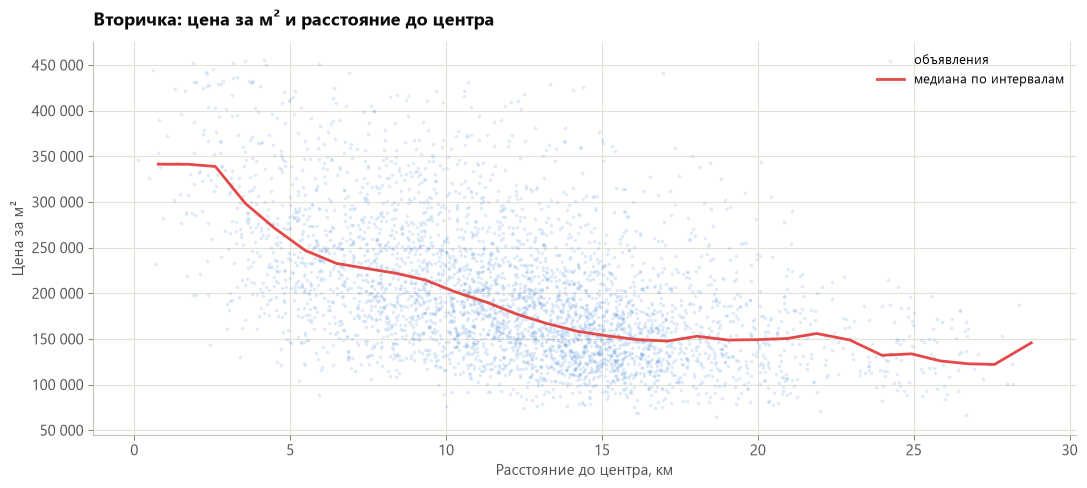

In [6]:
_ = plot_price_vs_factor(
    df_secondary, 'price_per_sqm', 'to_center_km',
    title='Вторичка: цена за м² и расстояние до центра',
    xlabel='Расстояние до центра, км',
)

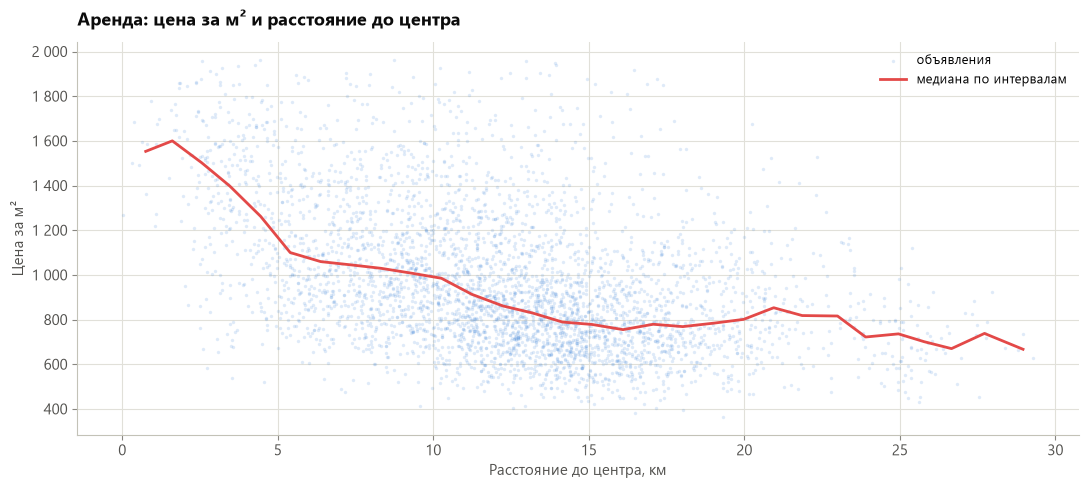

In [7]:
_ = plot_price_vs_factor(
    df_rentals, 'rent_per_sqm', 'to_center_km',
    title='Аренда: цена за м² и расстояние до центра',
    xlabel='Расстояние до центра, км',
)

### Выводы по 8.1.1

**Оба фактора связаны с ценой отрицательно и умеренно сильно** — чем дальше, тем дешевле, корреляция в районе −0.45…−0.55. Это средняя по силе связь: расстояние объясняет заметную часть цены, но далеко не всю.

**Метро против центра — почти ничья, но с важной оговоркой:**

| Сегмент | До метро (Пирсон / Спирмен) | До центра (Пирсон / Спирмен) |
|---|---|---|
| Аренда | −0.449 / −0.500 | −0.448 / −0.450 |
| Вторичка | −0.490 / −0.546 | −0.513 / −0.521 |
| Новостройки | −0.356 / −0.402 | −0.436 / −0.413 |

По Пирсону чуть сильнее расстояние до центра, по Спирмену — до метро. Само по себе это расхождение и есть находка: **у метро Спирмен заметно выше Пирсона** (−0.546 против −0.490 на вторичке), а у центра они почти равны. Значит, связь с метро монотонная, но **нелинейная**, а с центром — ближе к линейной.

Графики это подтверждают: цена резко падает в первые ~25-30 минут до метро, а дальше кривая почти выравнивается — разница между 60 и 120 минутами уже почти не влияет на цену. У расстояния до центра падение более плавное и растянутое, с выходом на плато после ~15 км.

**Практический смысл:** первые минуты пешком до метро стоят дорого, а после определённого порога метро перестаёт быть фактором цены вообще. С центром иначе — там каждый километр «стоит» примерно одинаково на всём диапазоне.

**У новостроек связь с метро самая слабая** (−0.356) — застройщики строят там, где есть свободная земля, а не там, где удобное метро.

**Проверка на Новой Москве:** если её не исключать, корреляции подскакивают с ~−0.5 до ~−0.65. То есть примерно треть видимого «эффекта расстояния» — это на самом деле не плавный градиент цены по километрам, а отдельный дешёвый кластер Новой Москвы, который просто далеко. Ещё один аргумент, почему её правильно считать отдельно.

## 8.1.2 Регрессионная модель прогноза цены за м²

Задача: по характеристикам объекта предсказать его цену за м².

**Что важно в постановке:**

- **Целевая переменная — `price_per_sqm`, а не `price_rub`.** Общая цена почти полностью определяется площадью, и модель бы просто выучила «площадь × ставка», ничего не сказав о рынке.
- **`is_premium` в признаки не берём.** Эта колонка сама посчитана из цены (порог IQR), то есть модель получила бы подсказку с ответом — это утечка целевой переменной (data leakage), метрики были бы отличные, а модель бесполезная.
- **`price_rub` тоже не берём** по той же причине: это цена за м², умноженная на площадь.
- **Категориальные признаки** (тип дома, ремонт, округ, тип продавца) превращаем в набор бинарных колонок — one-hot кодирование, регрессия работает только с числами.
- **Данные делим на обучение и тест (80/20).** Модель учится только на обучающей части, а качество меряем на тестовой — на объектах, которых она не видела. Иначе мы бы измеряли не способность предсказывать, а способность запоминать.

In [8]:
numeric_cols = [
    'total_area', 'living_area', 'kitchen_area', 'rooms',
    'floor', 'total_floors', 'building_year', 'ceiling_height',
    'metro_distance_min', 'to_center_km', 'mortgage_rate_at_listing',
    'has_balcony', 'is_new_moscow',
]
categorical_cols = ['building_type', 'renovation', 'metro_distance_type', 'seller_type', 'okrug']

print("=== Модель на всех данных (вторичка) ===")
model_all, coef_all, metrics_all, test_all = fit_price_model(
    df_secondary, 'price_per_sqm', numeric_cols, categorical_cols
)

=== Модель на всех данных (вторичка) ===
Объектов: 50,000 (обучение 40,000 / тест 10,000), признаков: 33
R²   = 0.822 — доля разброса цены, объяснённая моделью
MAE  = 33 536 руб/м² — средняя ошибка прогноза
RMSE = 47 430 руб/м² — та же ошибка  но с большим штрафом за грубые промахи
Для сравнения  средняя цена в тесте: 195 981 руб/м²
Относительная ошибка: 17.1%


Теперь то же самое, но без премиум-сегмента — проверим, насколько именно премиум портит качество прогноза.

In [9]:
print("=== Модель без премиум-сегмента (вторичка) ===")
model_np, coef_np, metrics_np, test_np = fit_price_model(
    df_secondary[~df_secondary['is_premium']], 'price_per_sqm', numeric_cols, categorical_cols
)

=== Модель без премиум-сегмента (вторичка) ===
Объектов: 47,285 (обучение 37,828 / тест 9,457), признаков: 33
R²   = 0.797 — доля разброса цены, объяснённая моделью
MAE  = 27 775 руб/м² — средняя ошибка прогноза
RMSE = 36 914 руб/м² — та же ошибка  но с большим штрафом за грубые промахи
Для сравнения  средняя цена в тесте: 177 256 руб/м²
Относительная ошибка: 15.7%


### Коэффициенты модели

Коэффициент показывает, на сколько рублей за м² меняется прогноз при изменении признака на единицу (для бинарных — при переходе из 0 в 1), если остальные признаки не меняются.

In [10]:
print("=== Топ-15 признаков по силе влияния (модель без премиума) ===")
print(coef_np.head(15).to_string(index=False))

=== Топ-15 признаков по силе влияния (модель без премиума) ===
                 Признак  Коэффициент
               okrug_VAO    -149061.4
              okrug_YuAO    -143694.1
              okrug_SVAO    -141883.3
               okrug_SAO    -124730.2
              okrug_SZAO     -88140.7
             okrug_YuZAO     -84783.7
           is_new_moscow     -80040.3
               okrug_ZAO     -76916.3
               okrug_NAO     -65671.5
     renovation_designer      53645.5
metro_distance_type_walk      45786.4
building_type_khrushchev     -33585.8
         renovation_euro      24843.4
             okrug_ZelAO     -23805.8
    building_type_stalin      22749.8


### Прогноз против факта

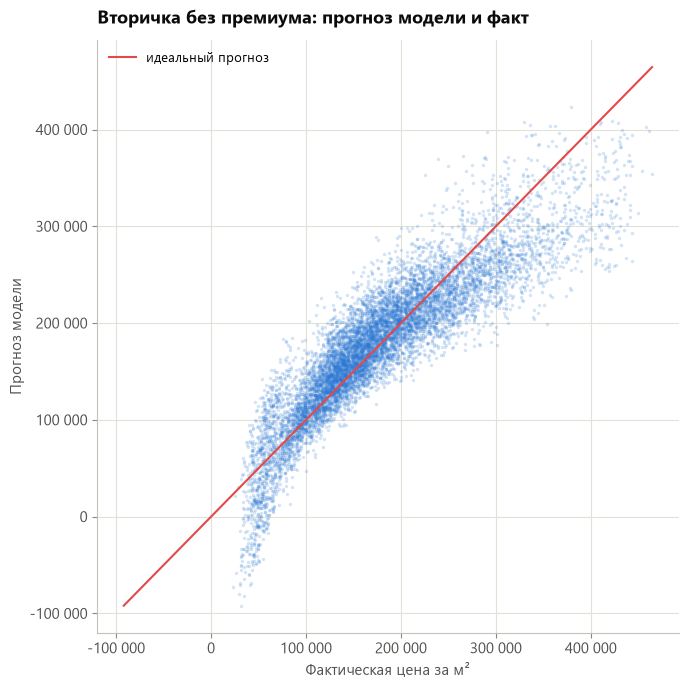

In [11]:
X_test_np, y_test_np, y_pred_np = test_np
plot_predictions(y_test_np, y_pred_np, 'Вторичка без премиума: прогноз модели и факт')

### Выводы по 8.1.2

**Качество модели:**

| Модель | R² | MAE | Относительная ошибка |
|---|---|---|---|
| Все данные | 0.822 | 33 536 руб/м² | 17.1% |
| Без премиум-сегмента | 0.797 | 27 775 руб/м² | 15.7% |

Здесь важная ловушка в чтении метрик: **R² выше у модели на всех данных, но ошибка при этом больше**. R² показывает долю *разброса*, объяснённую моделью, а вместе с премиумом разброс цен сам по себе намного больше. То есть R² нельзя сравнивать между разными наборами данных, для этого честнее MAE. По MAE видно: без премиума модель точнее почти на 6 тыс. руб/м². **Премиум-сегмент — главный источник ошибок**, его цена определяется не характеристиками квартиры, а статусом локации, чего в признаках попросту нет.

**Что говорят коэффициенты** (модель без премиума, база сравнения по округу — ЦАО):

- **Первые девять мест по силе влияния — округа.** ВАО −149 тыс., ЮАО −144 тыс., СВАО −142 тыс. руб/м² относительно ЦАО. Локация обходит все характеристики самого жилья вместе взятые — тот же вывод, что был в 7.4 про класс новостроек
- **`is_new_moscow` −80 тыс.** — и это *сверх* эффекта округа, то есть Новая Москва дешевеет дважды
- **Дизайнерский ремонт +53.6 тыс., евроремонт +24.8 тыс.** — согласуется с 7.2, где на аренде вышло +43.7% и +25.3%
- **`metro_distance_type_walk` +45.8 тыс.** — если до метро можно дойти пешком, а не ехать, это стоит почти как дизайнерский ремонт
- **Хрущёвка −33.6 тыс., сталинка +22.7 тыс.** — согласуется с 7.3: хрущёвка самый дешёвый тип, сталинка самый дорогой

**Важная оговорка про коэффициенты:** их нельзя сравнивать между признаками с разными шкалами. Коэффициент при `building_year` считается «на один год», при `total_area` — «на один м²», а у бинарных — сразу на весь переход из 0 в 1. Поэтому год постройки не попал в топ-15 не потому, что не важен, а потому что его вклад размазан по 90 годам. Честное сравнение важности признаков — отдельная задача 8.1.3.

**Ограничения модели, видные на графике «прогноз против факта»:**

1. **Для самых дешёвых объектов модель уходит в минус** — вплоть до −80 тыс. руб/м². Линейная регрессия не знает, что цена не может быть отрицательной, ничто её не ограничивает
2. **Облако точек изогнуто** — в середине диапазона прогнозы ложатся на диагональ хорошо, а на краях систематически смещаются. Признак того, что связь не совсем линейная
3. **Разброс растёт вместе с ценой** — дорогие объекты предсказываются заметно хуже дешёвых


## 8.1.3 Feature importance: что определяет попадание в премиум-сегмент

Задача — не предсказать число, а предсказать **да/нет**: попадёт объект в премиум-сегмент или нет. Это классификация, и решаем её случайным лесом (набор решающих деревьев, каждое из которых голосует за свой ответ).

**Что важно в постановке:**

- **Цену в признаки не берём вообще** — ни `price_per_sqm`, ни `price_rub`. `is_premium` посчитан прямо из цены по порогу IQR, так что любая цена среди признаков сделает задачу тривиальной и бессмысленной. Вопрос ставится именно так: можно ли по *физическим характеристикам* объекта понять, что он премиальный
- **Классы сильно несбалансированы** — премиума всего ~5%. Поэтому точность (accuracy) здесь бесполезна: модель, которая всегда говорит «не премиум», будет права в 95% случаев и при этом ничего не умеет. Смотрим на **ROC-AUC**, **precision** (какая доля предсказанных премиумов действительно премиум) и **recall** (какую долю реальных премиумов модель нашла)
- **`class_weight='balanced'`** заставляет модель считать ошибки на редком классе дороже, иначе она просто научится всегда отвечать «не премиум»

In [12]:
from src.classification import (
    fit_premium_classifier,
    feature_importance_table,
    permutation_importance_table,
    plot_importance,
)

clf, (X_train_c, X_test_c, y_train_c, y_test_c) = fit_premium_classifier(
    df_secondary, numeric_cols, categorical_cols
)

Объектов: 50,000 (обучение 40,000 / тест 10,000), признаков: 33
Доля премиума в выборке: 5.4%

ROC-AUC = 0.989

Отчёт по классам:
              precision    recall  f1-score   support

     обычный      0.991     0.979     0.985      9457
     премиум      0.702     0.840     0.764       543

    accuracy                          0.972     10000
   macro avg      0.846     0.910     0.875     10000
weighted avg      0.975     0.972     0.973     10000

Матрица ошибок (строки — факт, столбцы — прогноз):
               прогноз: обычный  прогноз: премиум
факт: обычный              9263               194
факт: премиум                87               456


### Две меры важности признаков

Считаем важность двумя разными способами, потому что у каждого свои слабости:

1. **Встроенная важность случайного леса** — считается при обучении по тому, насколько признак улучшал разбиения в деревьях. Быстрая, но с известным перекосом: она завышает важность непрерывных признаков с большим числом уникальных значений (площадь, координаты) просто потому, что по ним больше способов разбить данные.
2. **Важность через перемешивание (permutation importance)** — берём обученную модель, случайно перемешиваем значения одного признака и смотрим, насколько просело качество. Если модель ничего не потеряла — признак ей не нужен. Считается на **тестовых** данных, поэтому честнее и не зависит от типа признака.

Если оба метода дают похожий топ — результату можно доверять.

=== Встроенная важность признаков (топ-15) ===
                 Признак  Важность
            to_center_km    0.4058
      metro_distance_min    0.1645
metro_distance_type_walk    0.0525
              okrug_YuAO    0.0392
               okrug_VAO    0.0389
              okrug_SVAO    0.0375
               okrug_SAO    0.0334
           is_new_moscow    0.0246
           building_year    0.0185
     renovation_designer    0.0165
              total_area    0.0151
             living_area    0.0149
            kitchen_area    0.0148
             okrug_YuZAO    0.0137
                   floor    0.0127


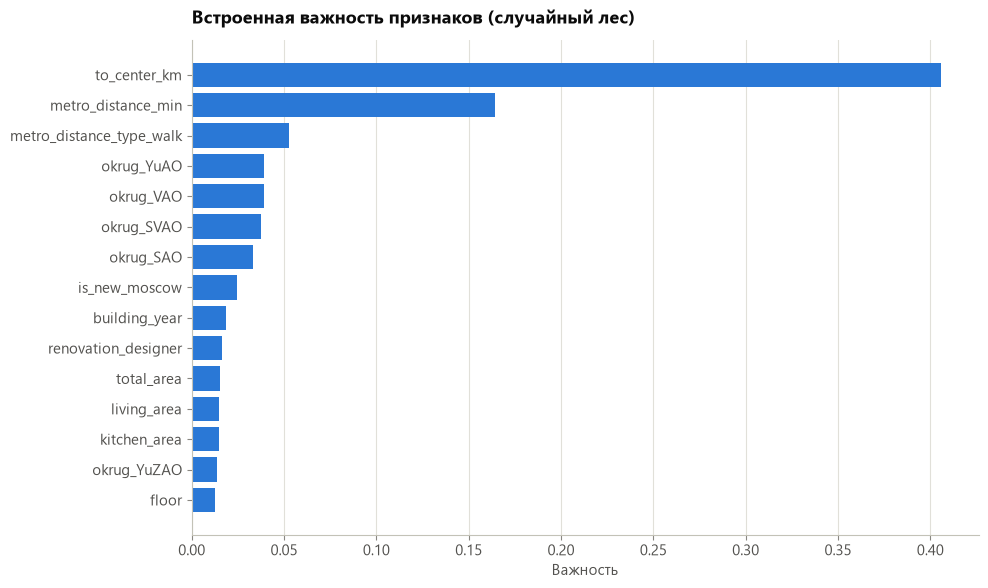

In [13]:
imp_builtin = feature_importance_table(clf, X_train_c, top=15)
print("=== Встроенная важность признаков (топ-15) ===")
print(imp_builtin.to_string(index=False))

plot_importance(imp_builtin, 'Важность', 'Встроенная важность признаков (случайный лес)')

=== Важность через перемешивание, по падению ROC-AUC (топ-15) ===
                 Признак  Падение ROC-AUC
            to_center_km           0.1051
              okrug_YuAO           0.0108
               okrug_SAO           0.0108
              okrug_SVAO           0.0105
      metro_distance_min           0.0094
               okrug_VAO           0.0085
     renovation_designer           0.0057
             okrug_YuZAO           0.0018
building_type_khrushchev           0.0016
renovation_no_renovation           0.0012
         renovation_euro           0.0011
               okrug_ZAO           0.0009
     building_type_panel           0.0008
    building_type_stalin           0.0007
           is_new_moscow           0.0007


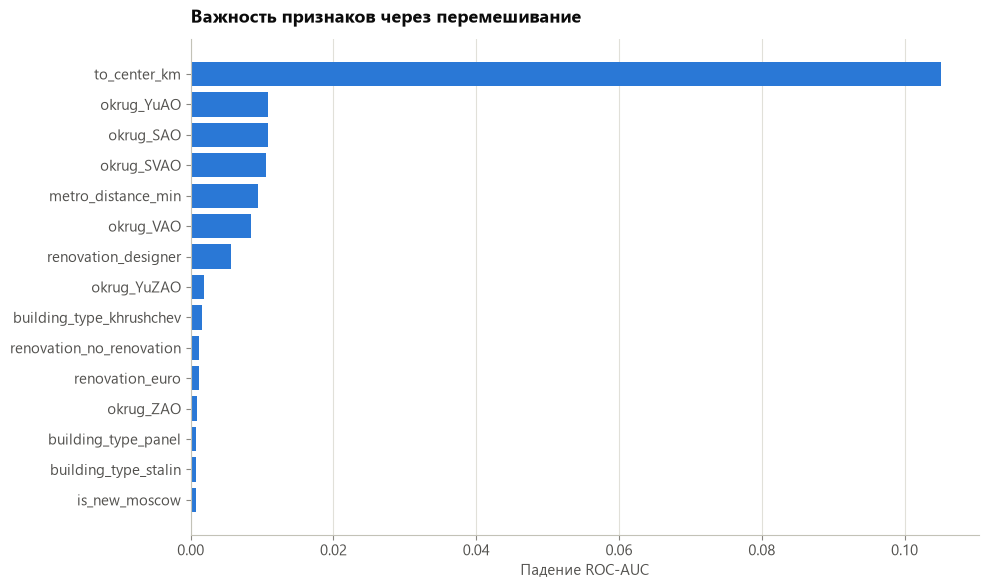

In [14]:
imp_perm = permutation_importance_table(clf, X_test_c, y_test_c, top=15)
print("=== Важность через перемешивание, по падению ROC-AUC (топ-15) ===")
print(imp_perm.to_string(index=False))

plot_importance(imp_perm, 'Падение ROC-AUC', 'Важность признаков через перемешивание')

### Выводы по 8.1.3

**Качество классификатора:** ROC-AUC = 0.989. Из 543 премиум-объектов в тесте модель нашла 456 (recall 0.840), при этом из всех её «премиумных» предсказаний верными оказались 70% (precision 0.702). Ложных срабатываний 194, пропущено 87.

Само по себе это уже вывод: **премиум-статус почти полностью предсказуем по физическим характеристикам объекта, без единого взгляда на цену.** «Премиум» — не какое-то неуловимое качество жилья, а вполне вычислимая вещь.

**Что именно его определяет — оба метода сходятся:**

| Признак | Встроенная важность | Через перемешивание |
|---|---|---|
| `to_center_km` | **0.406** | **0.105** |
| `metro_distance_min` | 0.165 | 0.009 |
| округа (все вместе) | ~0.16 | ~0.04 |
| `renovation_designer` | 0.017 | 0.006 |
| площади (общая, жилая, кухня) | ~0.045 | вне топ-15 |

**Расстояние до центра доминирует с огромным отрывом** — по перемешиванию оно почти в 10 раз важнее следующего признака. Дальше идут метро и округа, то есть снова география. Характеристики самой квартиры — площадь, этаж, год постройки — либо в самом низу, либо вообще не попадают в топ-15 по честной метрике.

**Вывод, окончательно закрывающий тему премиума:** попадание в премиум-сегмент определяется географией, а не свойствами жилья. Это третье независимое подтверждение одного и того же — раньше то же самое показали 7.4 (economy-класс в центре дороже премиума на окраине) и коэффициенты регрессии в 8.1.2 (округа заняли первые девять мест).

**Где методы разошлись и почему это полезно знать:**

- `metro_distance_type_walk` — встроенная важность ставит его на 3-е место (0.053), а из топ-15 по перемешиванию он выпадает вообще. Причина не в ошибке, а в **корреляции признаков**: пешая доступность метро почти всегда означает центральное расположение, поэтому после `to_center_km` этот признак не добавляет модели почти ничего нового
- **Площади** попали в топ-15 встроенной важности, но полностью выпали из перемешивания — классический перекос встроенной метрики в сторону непрерывных признаков с большим числом уникальных значений: по ним просто больше способов разбить данные, деревья используют их часто, а пользы мало

Именно ради таких расхождений и стоит считать важность двумя способами, а не доверять одной цифре.

## 8.2 Временная динамика рынка

Работаем с `district_prices_monthly` — это независимый источник помесячной статистики по районам (не производная от таблиц объявлений). Период: 2020-01 — 2026-04, 76 месяцев.


### 8.2.1 Динамика цен и ставки ЦБ / ипотеки

Сводим районы к общегородскому ряду: цены — медиана по районам, ставки берём как есть (внутри месяца они одинаковы для всех районов, это проверено).

In [15]:
from src.time_series import (
    city_monthly_series, plot_price_index, plot_price_and_rate,
    lagged_correlation, plot_lagged_correlation,
    forecast_linear_trend, plot_forecast,
)

df_monthly = pd.read_csv(PROCESSED_DIR / 'clean_district_prices_monthly.csv', parse_dates=['year_month'])
city = city_monthly_series(df_monthly)

print(f"Период: {city.index.min():%Y-%m} — {city.index.max():%Y-%m}, месяцев: {len(city)}")
print("\nРост за весь период:")
for col, label in [('secondary', 'Вторичка'), ('newbuild', 'Новостройки'), ('rental', 'Аренда')]:
    growth = (city[col].iloc[-1] / city[col].iloc[0] - 1) * 100
    print(f"  {label:12s} {city[col].iloc[0]:>10,.0f} -> {city[col].iloc[-1]:>10,.0f}  ({growth:+.1f}%)".replace(',', ' '))

print(f"\nКлючевая ставка: от {city['key_rate'].min()} до {city['key_rate'].max()}%")
print(f"Ипотечная ставка: от {city['mortgage_rate'].min()} до {city['mortgage_rate'].max()}%")

Период: 2020-01 — 2026-04, месяцев: 76

Рост за весь период:
  Вторичка        193 200 ->    299 700  (+55.1%)
  Новостройки     213 700 ->    329 300  (+54.1%)
  Аренда              805 ->      1 249  (+55.2%)

Ключевая ставка: от 4.25 до 21.0%
Ипотечная ставка: от 6.75 до 23.5%


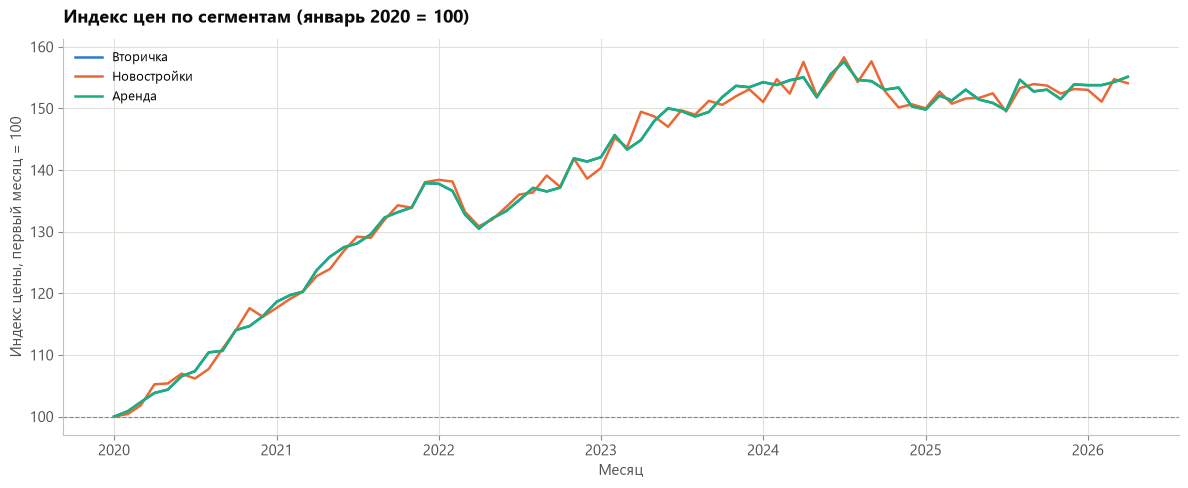

In [16]:
plot_price_index(
    city,
    cols=['secondary', 'newbuild', 'rental'],
    labels=['Вторичка', 'Новостройки', 'Аренда'],
    title='Индекс цен по сегментам (январь 2020 = 100)',
)

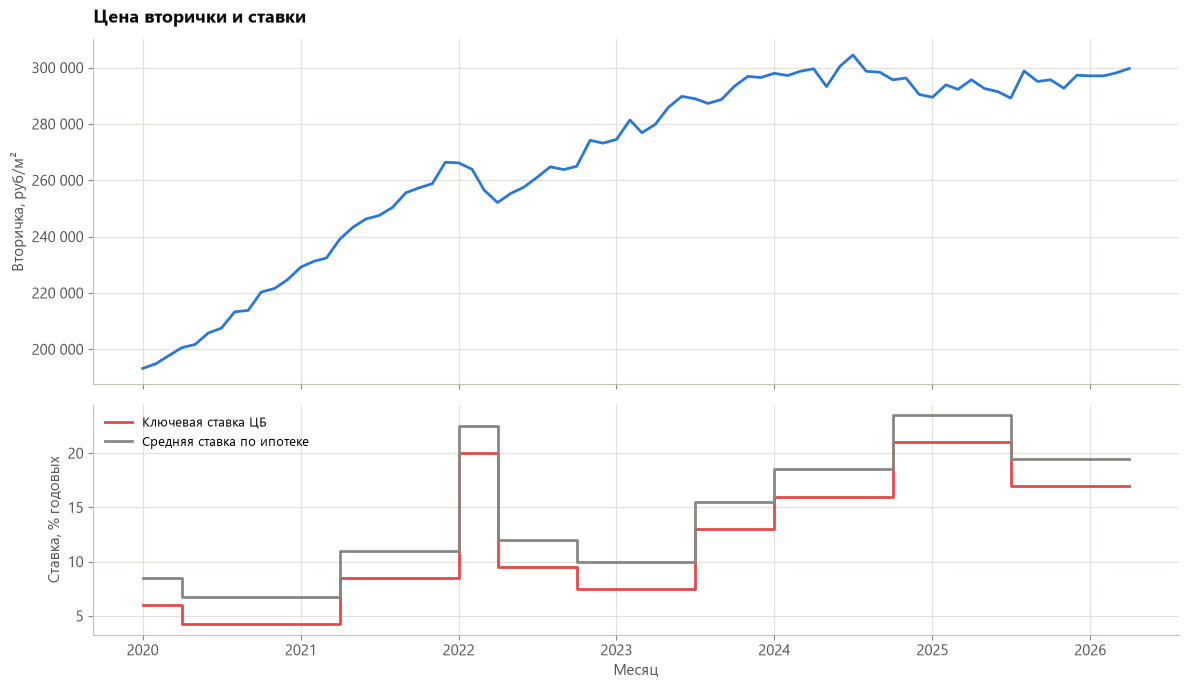

In [17]:
plot_price_and_rate(city, 'secondary', 'Вторичка', 'Цена вторички и ставки')

**Исправление вида графика — было / стало.** Раньше цена и ставки были нарисованы на одном графике с двумя осями Y: слева рубли за м², справа проценты. Такой график вводит в заблуждение. Взаимное положение двух шкал выбирается произвольно, поэтому «совпадение изгибов» линий может нарисовать сама настройка осей: сдвинь масштаб правой оси — и линии разойдутся или сойдутся. Теперь цена и ставки — две панели с общей шкалой времени: даты совпадают, а масштабы друг под друга не подгоняются.

Выводы раздела от этого не меняются: связь цены со ставкой проверяется не на глаз, а расчётом корреляции по лагам ниже. Для сравнения — прежний вариант (функция `plot_price_and_rate_dual_axis` оставлена в `src/time_series.py`, чтобы его можно было воспроизвести):

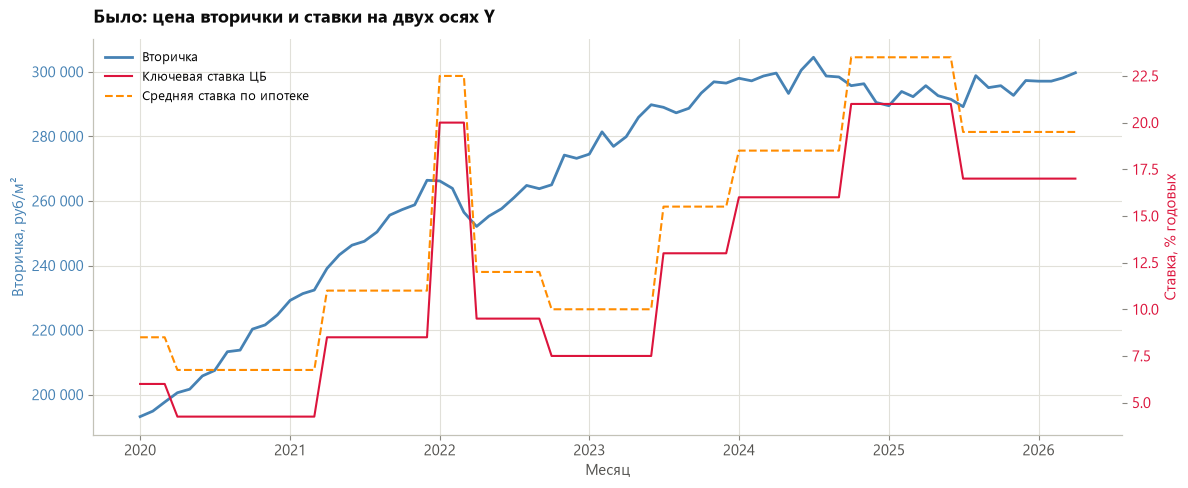

In [18]:
from src.time_series import plot_price_and_rate_dual_axis

plot_price_and_rate_dual_axis(city, 'secondary', 'Вторичка', 'Было: цена вторички и ставки на двух осях Y')

Теперь проверим связь формально. Ставка влияет на рынок не мгновенно — ипотека одобряется и сделки закрываются с задержкой, поэтому смотрим корреляцию прироста цены со ставкой, сдвинутой назад на 0-6 месяцев.

=== Корреляция прироста цены вторички со ставкой ЦБ ===
 Лаг, мес  Корреляция
        0      -0.481
        1      -0.511
        2      -0.429
        3      -0.341
        4      -0.276
        5      -0.278
        6      -0.299


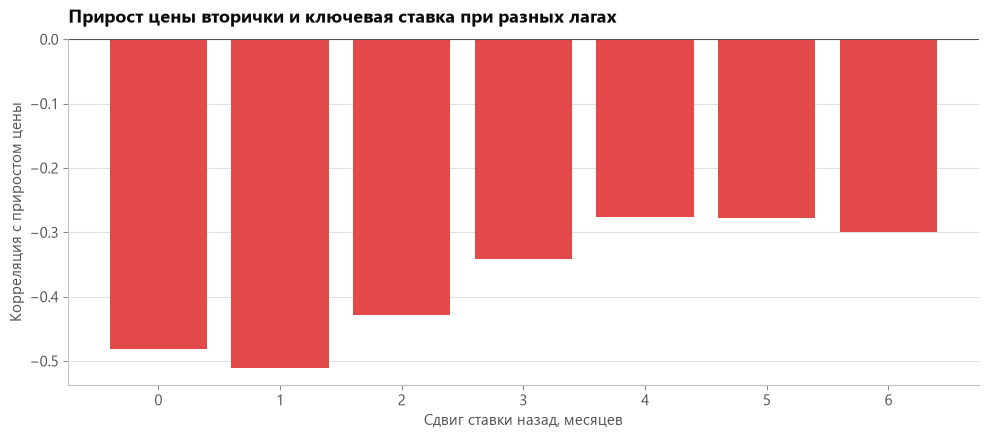

In [19]:
lag_table = lagged_correlation(city, 'secondary_mom', 'key_rate', max_lag=6)
print('=== Корреляция прироста цены вторички со ставкой ЦБ ===')
print(lag_table.to_string(index=False))

plot_lagged_correlation(lag_table, 'Прирост цены вторички и ключевая ставка при разных лагах')

In [20]:
print('=== То же для аренды ===')
lag_rental = lagged_correlation(city, 'rental_mom', 'key_rate', max_lag=6)
print(lag_rental.to_string(index=False))

print('\n=== Прирост цены вторички и ипотечная ставка ===')
lag_mortgage = lagged_correlation(city, 'secondary_mom', 'mortgage_rate', max_lag=6)
print(lag_mortgage.to_string(index=False))

=== То же для аренды ===
 Лаг, мес  Корреляция
        0      -0.478
        1      -0.507
        2      -0.428
        3      -0.339
        4      -0.274
        5      -0.275
        6      -0.296

=== Прирост цены вторички и ипотечная ставка ===
 Лаг, мес  Корреляция
        0      -0.481
        1      -0.511
        2      -0.429
        3      -0.341
        4      -0.276
        5      -0.278
        6      -0.299


### Выводы по 8.2.1

**Все три сегмента выросли почти одинаково: +55.1% вторичка, +54.1% новостройки, +55.2% аренда.** На графике индекса их линии практически накладываются друг на друга — рынок двигался как единое целое, без расхождения сегментов.

**Форма движения — рост до 2024 года, потом плато.** Индекс дошёл примерно до 155 к началу 2024 и с тех пор колеблется в диапазоне 150-158, не пробивая его ни вверх, ни вниз уже два с лишним года.

**Два заметных провала, и оба совпадают со скачками ставки:**
- начало 2022 — ставка взлетает до 21%, индекс падает со 138 до 131
- конец 2024 — ставка снова 21%, индекс сползает со 158 до 150

**Связь подтверждается формально, с задержкой в один месяц:**

| Лаг | 0 | **1** | 2 | 3 | 4 | 5 | 6 |
|---|---|---|---|---|---|---|---|
| Корреляция | −0.481 | **−0.511** | −0.429 | −0.341 | −0.276 | −0.278 | −0.299 |

Максимум по модулю приходится на лаг 1 месяц, дальше связь затухает. То есть **рынок реагирует на изменение ставки примерно через месяц, и эффект короткий** — к третьему-четвёртому месяцу связь ослабевает вдвое. Знак отрицательный: выше ставка → медленнее рост цен, что экономически ожидаемо.

**Две особенности самих данных, которые стоит знать:**

1. **Ипотечная ставка даёт ровно те же корреляции, что и ключевая** — до третьего знака (−0.481, −0.511, −0.429…). Значит в этом датасете ипотечная ставка жёстко привязана к ключевой и не несёт отдельной информации. Использовать обе как независимые факторы бессмысленно — это один и тот же сигнал.
2. **Аренда реагирует на ставку практически идентично вторичке** (−0.478 против −0.481 при лаге 0). На реальном рынке так обычно не бывает: аренда зависит от ипотечной ставки слабее и с большей задержкой, потому что арендатор кредит не берёт. Это, скорее всего, следствие того, что все три ряда в датасете порождены одним механизмом.

### 8.2.2 Сверка с официальной статистикой на всём периоде

Чтобы сравнение было честным, обе величины взвешиваем одинаково — по числу объявлений в районе. Так из сравнения уходит эффект разного состава районов.

In [21]:
import sqlite3

conn = sqlite3.connect(str(PROCESSED_DIR / 'moscow_realty.db'))
check = pd.read_sql_query('SELECT * FROM v_official_check', conn, parse_dates=['year_month'])
conn.close()

print(f"Строк в view: {len(check):,} (район × месяц), месяцев: {check['year_month'].nunique()}")

check['w_our'] = check['our_avg_price'] * check['n_listings']
check['w_official'] = check['official_price'] * check['n_listings']

monthly = check.groupby('year_month').agg(
    listings=('n_listings', 'sum'),
    w_our=('w_our', 'sum'),
    w_official=('w_official', 'sum'),
)
monthly['our_price'] = monthly['w_our'] / monthly['listings']
monthly['official_price'] = monthly['w_official'] / monthly['listings']
monthly['difference_pct'] = (monthly['our_price'] / monthly['official_price'] - 1) * 100

print(f"\nСреднее расхождение за период: {monthly['difference_pct'].mean():.1f}%")
print(f"Разброс расхождения: от {monthly['difference_pct'].min():.1f}% до {monthly['difference_pct'].max():.1f}%")

Строк в view: 8,086 (район × месяц), месяцев: 76

Среднее расхождение за период: -32.3%
Разброс расхождения: от -34.3% до -30.7%


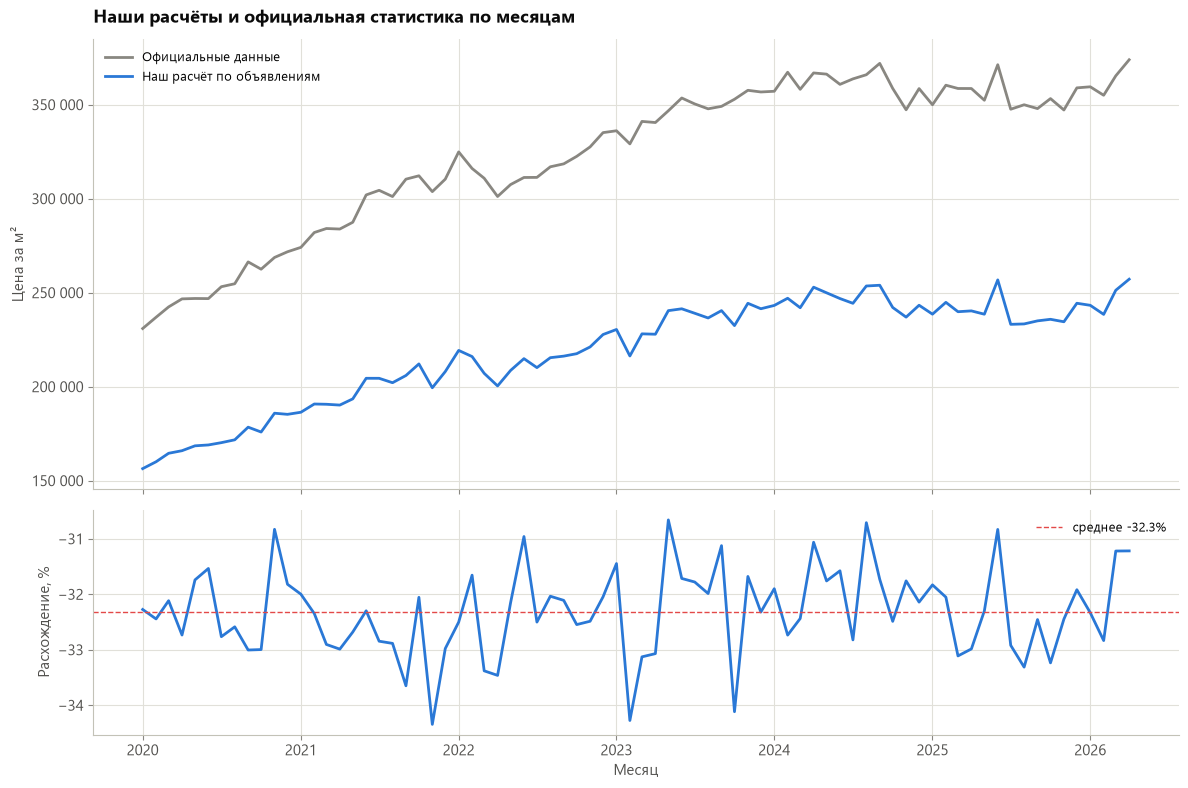

In [22]:
import matplotlib.pyplot as plt
from matplotlib import ticker
from src.plot_style import ACCENT, MUTED, PRIMARY, THOUSANDS

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True,
                               gridspec_kw={'height_ratios': [2, 1]})

ax1.plot(monthly.index, monthly['official_price'], color=MUTED, linewidth=2, label='Официальные данные')
ax1.plot(monthly.index, monthly['our_price'], color=PRIMARY, linewidth=2, label='Наш расчёт по объявлениям')
ax1.set_ylabel('Цена за м²')
ax1.yaxis.set_major_formatter(THOUSANDS)
ax1.set_title('Наши расчёты и официальная статистика по месяцам')
ax1.grid(True)
ax1.legend()

ax2.plot(monthly.index, monthly['difference_pct'], color=PRIMARY, linewidth=2)
ax2.axhline(monthly['difference_pct'].mean(), color=ACCENT, linestyle='--', linewidth=1,
            label=f"среднее {monthly['difference_pct'].mean():.1f}%")
ax2.set_ylabel('Расхождение, %')
ax2.set_xlabel('Месяц')
ax2.grid(True)
ax2.legend()

plt.tight_layout()
plt.show()

In [23]:
# Совпадает ли динамика, если уровни отличаются
monthly['our_mom'] = monthly['our_price'].pct_change() * 100
monthly['official_mom'] = monthly['official_price'].pct_change() * 100

corr_levels = monthly['our_price'].corr(monthly['official_price'])
corr_mom = monthly['our_mom'].corr(monthly['official_mom'])

print(f"Корреляция уровней цен:      {corr_levels:.3f}")
print(f"Корреляция помесячных приростов: {corr_mom:.3f}")

Корреляция уровней цен:      0.996
Корреляция помесячных приростов: 0.859


### Выводы по 8.2.2

**Наши расчёты по объявлениям систематически ниже официальной статистики на 32.3%** — и это не случайный шум, а устойчивое смещение: за все 76 месяцев расхождение не выходило за границы от −34.3% до −30.7%, то есть колеблется в коридоре всего 3.6 процентных пункта.

**При этом динамика совпадает почти идеально:**

| Что сравниваем | Корреляция |
|---|---|
| Уровни цен | 0.996 |
| Помесячные приросты | 0.859 |

Это и есть главный вывод: **два источника расходятся по уровню, но согласованно движутся во времени.** На верхнем графике видно две почти параллельные линии — наша идёт стабильно ниже официальной, повторяя все её изгибы, включая провал 2022 года и плато после 2024.

**Что это значит практически:** данные объявлений надёжны для всего **относительного** — сравнения районов между собой, процентных надбавок за ремонт или тип дома, динамики по времени, рейтингов окупаемости. Все выводы проекта до этого момента были именно такими, значит они устойчивы. Но для утверждений об **абсолютном** уровне цен («квартира в этом районе стоит N рублей за м²») брать нужно официальный ряд, иначе занизишь примерно на треть.

Причина расхождения из самих данных не определяется — это может быть разница в методике расчёта, в составе объектов или просто в калибровке источников. Важно, что смещение постоянное и его легко учесть.

Отдельно отмечу методический момент: обе величины взвешены **по одному и тому же числу объявлений в районе**. Без этого часть расхождения объяснялась бы просто разным составом районов, а не разницей в самих ценах.

### 8.2.3 Прогноз цен на ближайшие месяцы

Метод намеренно простой: берём последние 24 месяца, проводим через них прямую линию тренда и продлеваем её на 6 месяцев вперёд.

**Что этот прогноз не умеет:** он не знает про ставку ЦБ, сезонность, кризисы и вообще любые внешние события. Это ответ на вопрос «сколько будет, если всё продолжится ровно как сейчас», а не настоящее прогнозирование. Для серьёзного прогноза нужны модели временных рядов с учётом внешних факторов — это отдельная задача.

=== Прогноз цены вторички ===
Тренд последних 24 месяцев: -24 руб/м² в месяц
Последний факт (2026-04): 299 700 руб/м²

  2026-05:    295 289 руб/м²
  2026-06:    295 265 руб/м²
  2026-07:    295 241 руб/м²
  2026-08:    295 217 руб/м²
  2026-09:    295 193 руб/м²
  2026-10:    295 169 руб/м²

Итого за 6 месяцев: -1.5%


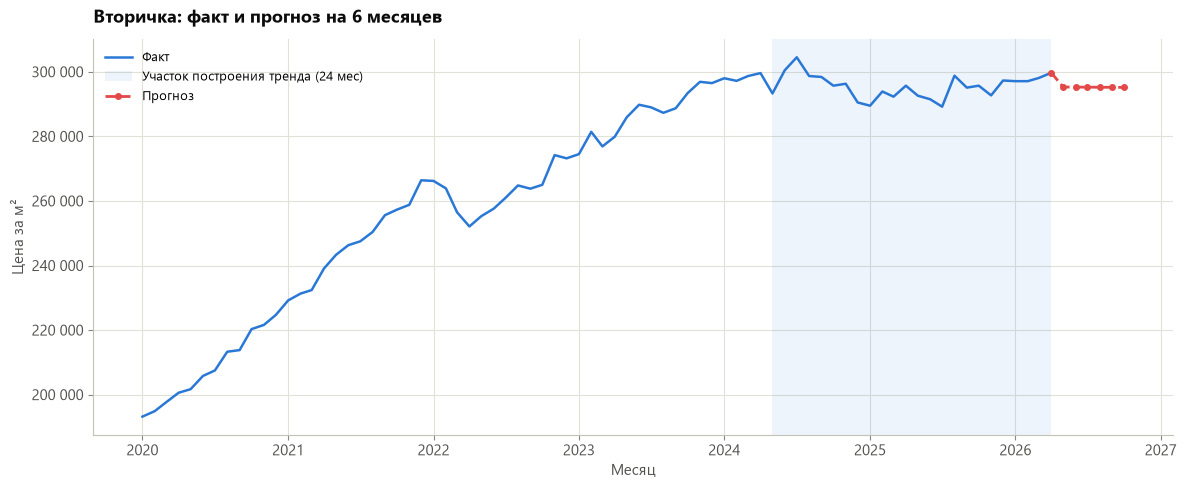

In [24]:
forecast_secondary, slope_secondary = forecast_linear_trend(city, 'secondary', history_months=24, periods=6)

print('=== Прогноз цены вторички ===')
print(f"Тренд последних 24 месяцев: {slope_secondary:+,.0f} руб/м² в месяц".replace(',', ' '))
print(f"Последний факт ({city.index[-1]:%Y-%m}): {city['secondary'].iloc[-1]:,.0f} руб/м²".replace(',', ' '))
print()
for date, value in forecast_secondary.items():
    print(f"  {date:%Y-%m}: {value:>10,.0f} руб/м²".replace(',', ' '))

change = (forecast_secondary.iloc[-1] / city['secondary'].iloc[-1] - 1) * 100
print(f"\nИтого за 6 месяцев: {change:+.1f}%")

plot_forecast(city, 'secondary', forecast_secondary, 'Вторичка: факт и прогноз на 6 месяцев')

=== Прогноз цены аренды ===
Тренд последних 24 месяцев: -0.1 руб/м² в месяц
Последний факт (2026-04): 1 249 руб/м²
Через 6 месяцев: 1 230 руб/м² (-1.5%)


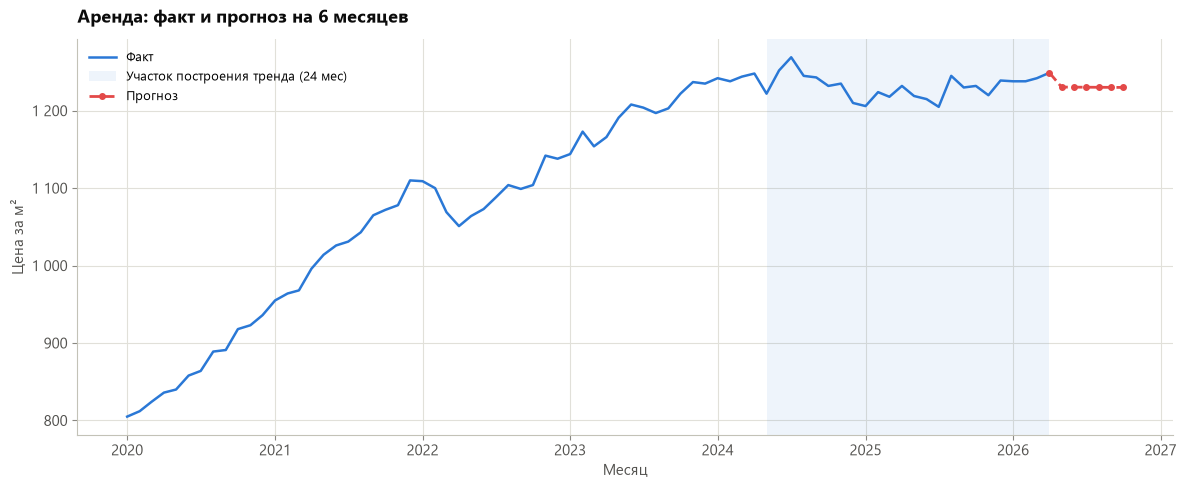

In [25]:
forecast_rental, slope_rental = forecast_linear_trend(city, 'rental', history_months=24, periods=6)

print('=== Прогноз цены аренды ===')
print(f"Тренд последних 24 месяцев: {slope_rental:+.1f} руб/м² в месяц")
print(f"Последний факт ({city.index[-1]:%Y-%m}): {city['rental'].iloc[-1]:,.0f} руб/м²".replace(',', ' '))
change_rental = (forecast_rental.iloc[-1] / city['rental'].iloc[-1] - 1) * 100
print(f"Через 6 месяцев: {forecast_rental.iloc[-1]:,.0f} руб/м² ({change_rental:+.1f}%)".replace(',', ' '))

plot_forecast(city, 'rental', forecast_rental, 'Аренда: факт и прогноз на 6 месяцев')

### Выводы по 8.2.3

**Тренд последних двух лет — практически горизонтальный.** Наклон линии по вторичке составляет −24 руб/м² в месяц при цене около 300 000 — это ноль в пределах точности. По аренде то же самое: −0.1 руб/м² в месяц. Прогноз на 6 месяцев вперёд даёт −1.5% по обоим сегментам, то есть **модель предсказывает не рост и не падение, а продолжение плато**.

Это согласуется с тем, что мы увидели в 8.2.1: рынок стоит на месте с начала 2024 года, и всё это время ключевая ставка держится на 17-21%. Прогноз просто продлевает уже существующую стагнацию.

**Как читать график:** линия прогноза начинается чуть ниже последней фактической точки. Это не ошибка — прогноз строится по линии тренда за 24 месяца, а не привязывается к последнему значению. Апрель 2026 оказался выше тренда, поэтому виден небольшой разрыв. Такая «непривязанность» — свойство метода: он показывает, где проходит средняя линия рынка, а не продолжает последнее случайное колебание.

**Чего этот прогноз не умеет** (и это важнее самих цифр):

- Не знает про ставку ЦБ — хотя в 8.2.1 мы только что показали, что она влияет на рынок с лагом в месяц. Модель, учитывающая ставку, была бы содержательно сильнее
- Не учитывает сезонность — а на рынке недвижимости она обычно есть
- Не переживёт никакого внешнего шока: любое событие вроде февраля 2022 года ломает такую экстраполяцию полностью
- Не даёт интервала неопределённости — только одну линию, хотя честный прогноз должен показывать коридор

Поэтому воспринимать его стоит строго как ориентир «если ничего не изменится», а не как настоящее прогнозирование. Полноценные модели временных рядов с внешними факторами — отдельная задача, в текущий пункт она не входит.

## 8.3 Гео-анализ


### 8.3.1 Кластеризация районов

Группируем районы методом k-средних по цене и транспортной доступности. Координаты в признаки намеренно **не** берём — иначе алгоритм просто нарежет карту на куски по географии. Интереснее сгруппировать районы по их рыночным свойствам, а потом посмотреть на карту и проверить, совпали ли группы с географией.

Признаки обязательно стандартизуются: цена измеряется сотнями тысяч, расстояние — километрами, и без приведения к общей шкале цена заглушила бы всё остальное.

In [26]:
from src.geo import (
    plot_heatmap, choose_clusters, cluster_districts,
    plot_clusters_map, plot_price_by_metro_line,
)

district_features = df_secondary[~df_secondary['is_new_moscow']].groupby('district').agg(
    price=('price_per_sqm', 'median'),
    to_center=('to_center_km', 'median'),
    metro_min=('metro_distance_min', 'median'),
    lat=('lat', 'median'),
    lon=('lon', 'median'),
)

features = district_features[['price', 'to_center', 'metro_min']]
print(f"Районов для кластеризации: {len(features)}")

scores = choose_clusters(features)
print('\n=== Подбор числа кластеров ===')
print(scores.to_string(index=False))

Районов для кластеризации: 107



=== Подбор числа кластеров ===
 k  Силуэт  Инерция
 2   0.426    163.5
 3   0.492     91.6
 4   0.459     70.4
 5   0.398     52.2
 6   0.413     39.8
 7   0.423     34.5
 8   0.409     30.1


In [27]:
best_k = int(scores.loc[scores['Силуэт'].idxmax(), 'k'])
print(f"Лучшее число кластеров по силуэту: {best_k}")

clustered, summary = cluster_districts(features, n_clusters=best_k)
print('\n=== Портрет кластеров (медианы) ===')
print(summary.round(1).to_string())

Лучшее число кластеров по силуэту: 3

=== Портрет кластеров (медианы) ===
            price  to_center  metro_min  Районов
cluster                                         
0        210300.0       10.4       27.0       63
1        143350.0       15.4       60.0       33
2        415800.0        3.2       21.0       11


In [28]:
district_features['cluster'] = clustered['cluster']

for cluster in sorted(district_features['cluster'].unique()):
    names = district_features[district_features['cluster'] == cluster].sort_values('price', ascending=False)
    print(f"\n=== Кластер {cluster} ({len(names)} районов) ===")
    print('  ' + ', '.join(names.index[:8]) + ('...' if len(names) > 8 else ''))


=== Кластер 0 (63 районов) ===
  Strogino, Gagarinsky, Lomonosovsky, Prospekt Vernadskogo, Ramenki, Cheryomushki, Filyovsky Park, Troparyovo-Nikulino...

=== Кластер 1 (33 районов) ===
  Kurkino, Yuzhnoye Tushino, Severnoye Tushino, Severnoye Butovo, Solntsevo, Babushkinsky, Otradnoye, Yuzhnoye Medvedkovo...

=== Кластер 2 (11 районов) ===
  Khamovniki, Arbat, Tverskoy, Presnensky, Yakimanka, Zamoskvorechye, Meshchansky, Basmanny...


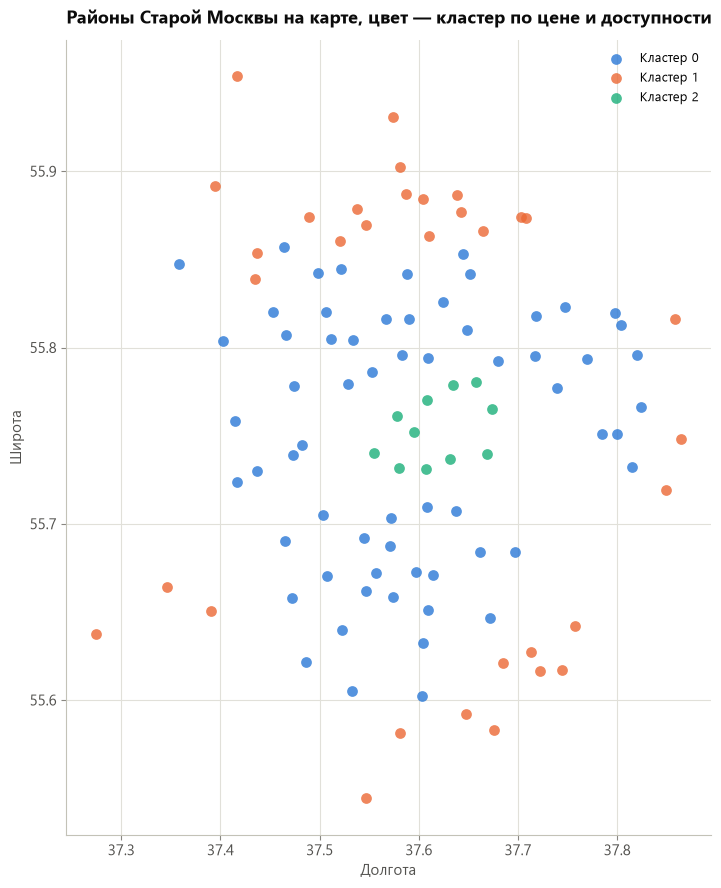

In [29]:
plot_clusters_map(
    district_features, 'lat', 'lon', 'cluster',
    'Районы Старой Москвы на карте, цвет — кластер по цене и доступности',
)

### Выводы по 8.3.1

**Оптимальное число кластеров — 3** (силуэт 0.492, заметно выше остальных вариантов). Рынок Старой Москвы естественным образом делится на три уровня:

| Кластер | Районов | Медиана цены | До центра | До метро |
|---|---|---|---|---|
| 2 — центр | 11 | 415 800 | 3.2 км | 21 мин |
| 0 — середина | 63 | 210 300 | 10.4 км | 27 мин |
| 1 — окраина | 33 | 143 350 | 15.4 км | 60 мин |

В элитный кластер попали Хамовники, Арбат, Тверской, Пресненский, Якиманка, Замоскворечье, Мещанский, Басманный — ровно те районы, которые и ожидаешь увидеть.

**Главное здесь — то, что мы координаты в признаки не давали.** Алгоритм группировал районы только по цене, удалённости от центра и времени до метро. Но на карте кластеры легли **идеальными концентрическими кольцами**: зелёное ядро в центре, синее кольцо вокруг него, оранжевые точки по периферии. Ни одного «чужого» района внутри чужого кольца практически нет.

Это сильный результат: он означает, что **рыночная стоимость района в Москве почти полностью определяется его положением относительно центра**, без исключений вроде отдельных дорогих анклавов на окраине. Если бы такие анклавы были, мы бы увидели зелёные или синие точки среди оранжевых.

**Ещё одна деталь — скачок по метро.** Между центром и серединой разница невелика (21 против 27 минут), а вот окраина отрывается резко — 60 минут, более чем вдвое. То есть по цене районы расположены плавно, а по транспортной доступности между «средним» и «дальним» поясом лежит настоящая пропасть.

### 8.3.2 Тепловые карты цен

Три тепловые карты: округ × тип дома и округ × год — на последовательной синей палитре (светлое = дёшево, тёмное = дорого), годовой прирост цен — на расходящейся «синий — серый — красный» с нулём посередине.

#### Карта 1: округ × тип дома

Последовательная палитра, строки отсортированы по медианной цене округа.

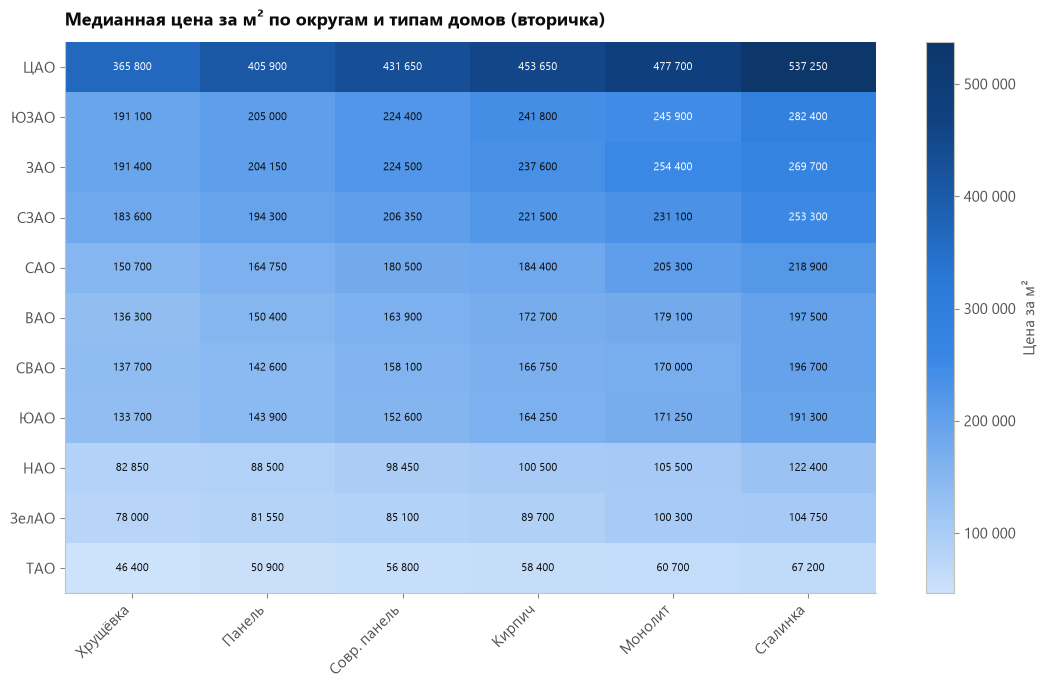

In [30]:
from src.price_factors import BUILDING_TYPE_RU
from src.names import OKRUG_NAMES_RU

heat_type = df_secondary.pivot_table(
    index='okrug', columns='building_type', values='price_per_sqm', aggfunc='median'
)
heat_type = heat_type.rename(columns=BUILDING_TYPE_RU)
# сортируем: округа по цене сверху вниз, типы домов по цене слева направо
heat_type = heat_type.loc[heat_type.median(axis=1).sort_values(ascending=False).index]
heat_type = heat_type[heat_type.median().sort_values().index]

plot_heatmap(
    heat_type.rename(index=OKRUG_NAMES_RU),
    title='Медианная цена за м² по округам и типам домов (вторичка)',
    cbar_label='Цена за м²',
)

#### Карта 2: округ × год

Та же последовательная палитра, но вторая ось — время. Видно и географию, и динамику сразу.

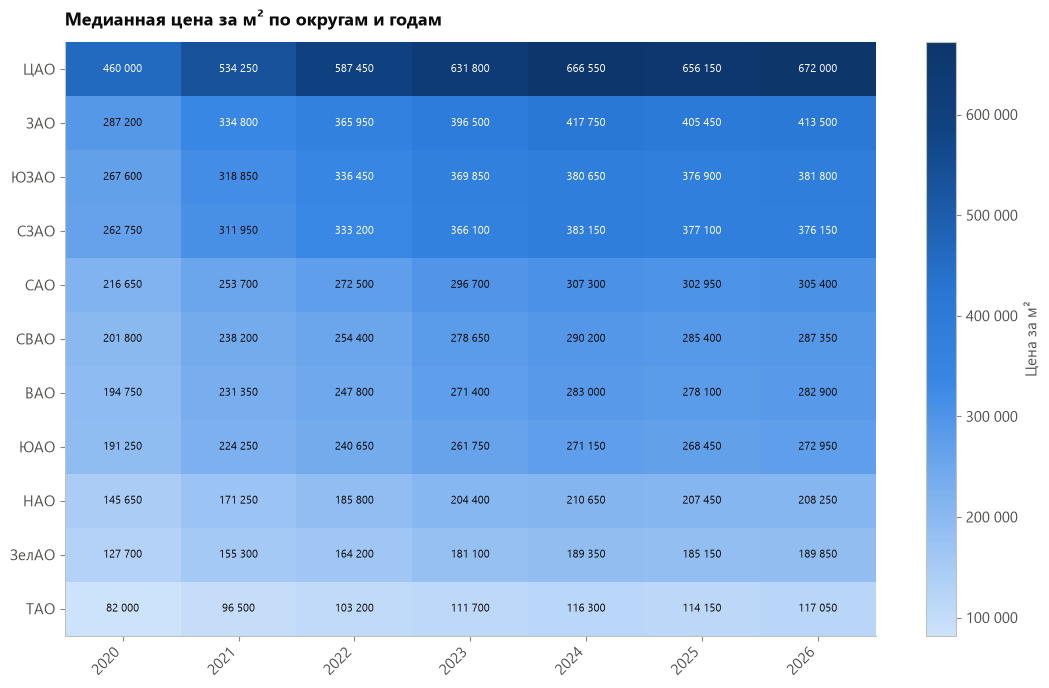

In [31]:
df_monthly['year'] = df_monthly['year_month'].dt.year

heat_year = df_monthly.pivot_table(
    index='okrug', columns='year', values='secondary_price_per_sqm', aggfunc='median'
)
heat_year = heat_year.loc[heat_year.median(axis=1).sort_values(ascending=False).index]

plot_heatmap(
    heat_year.rename(index=OKRUG_NAMES_RU),
    title='Медианная цена за м² по округам и годам',
    cbar_label='Цена за м²',
)

#### Карта 3: годовой прирост цен — расходящаяся палитра

Здесь величина уже другого рода: прирост может быть и положительным, и отрицательным, и осмысленная середина — ноль. Поэтому берём расходящуюся палитру с центром в нуле: красное — рост, синее — падение, светло-серое — рынок стоял на месте.

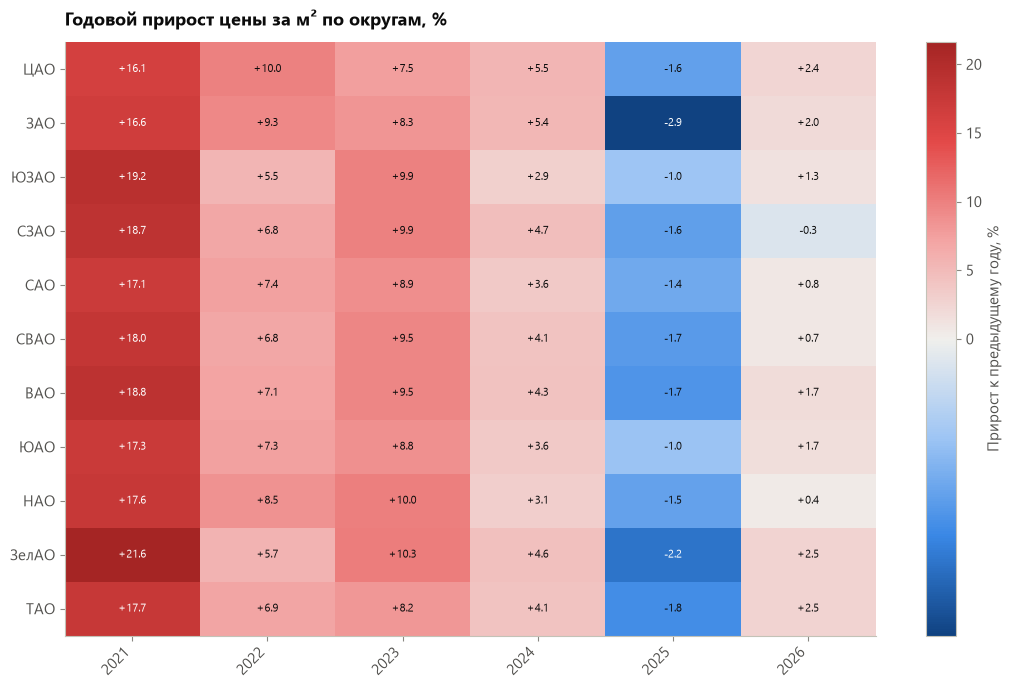

In [32]:
growth = heat_year.pct_change(axis=1) * 100
growth = growth.drop(columns=growth.columns[0])  # первый год не с чем сравнивать

plot_heatmap(
    growth.rename(index=OKRUG_NAMES_RU),
    title='Годовой прирост цены за м² по округам, %',
    cbar_label='Прирост к предыдущему году, %',
    diverging=True,
    center=0,
    fmt='{:+.1f}',
)

### Выводы по 8.3.2

**Карта «округ × тип дома» даёт самое наглядное подтверждение главного вывода проекта.** Верхняя строка (ЦАО) целиком тёмная, все остальные — светлые. Конкретно: **хрущёвка в ЦАО стоит 365 800 руб/м², а сталинка — лучший тип дома — в любом другом округе не дороже 282 400.** То есть худшее жильё в центре дороже лучшего жилья везде ещё. Разрыв между крайними ячейками (сталинка в ЦАО против хрущёвки в ТАО) — 11.6 раза.

При этом сам порядок типов домов слева направо одинаков во **всех** округах без исключения — цветовой градиент внутри каждой строки идёт ровно в одну сторону. Это визуально подтверждает вывод 7.3: надбавка за тип дома устойчива и не зависит от района, меняется только база, от которой она считается.

**Карта «округ × год» показывает, что рост шёл параллельно во всех округах** — строки светлеют слева направо синхронно, ни один округ не выбился из общей картины.

**Карта годового прироста (расходящаяся палитра) читается лучше всех трёх:**

- **2021 — сплошной тёмно-красный**, рост +16…+21.6% везде. Лидер — Зеленоград (+21.6%)
- дальше рост затухает: 2022 (+5.5…+10%), 2023 (+8…+10%), 2024 (+2.9…+5.5%)
- **2025 — единственный синий столбец**, весь рынок в минусе от −1.0% до −2.9%. Глубже всех просел ЗАО
- 2026 — почти белый, то есть рынок замер около нуля

**Отдельный вывод из равномерности цвета по вертикали:** ни один округ не живёт своей отдельной жизнью — вся Москва растёт и падает одновременно. Географических различий в *динамике* нет, они есть только в *уровне* цен.

### 8.3.3 Ветка метро и год открытия станции

Данные берём из `v_secondary_market_metro` — это view, который мы собрали в разделе 4: объявления, склеенные со справочником станций, откуда подтягивается `year_opened`.

Объектов: 38,807, веток: 12


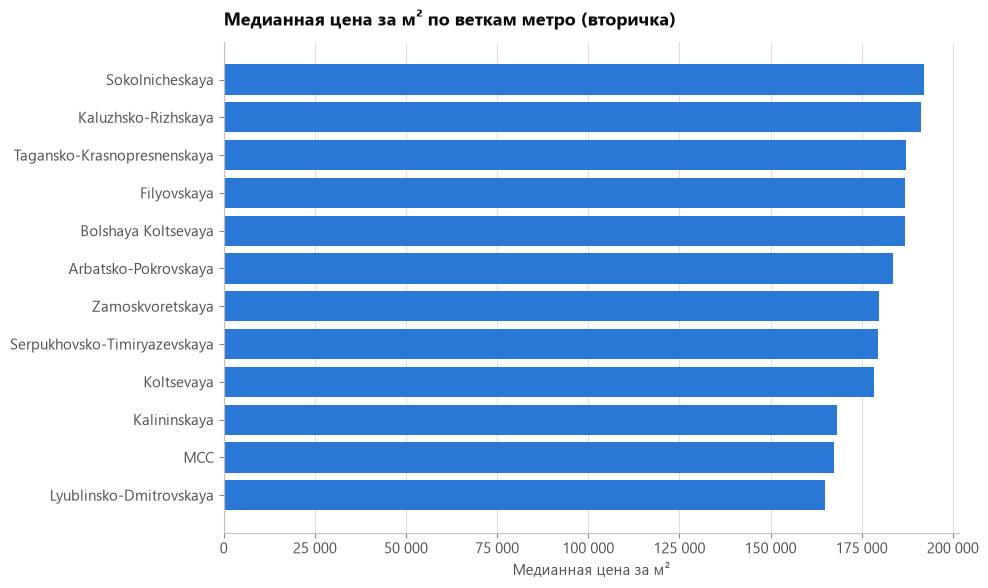

                              Медиана цены  Объявлений
metro_line                                            
Lyublinsko-Dmitrovskaya           164800.0        2330
MCC                               167400.0         545
Kalininskaya                      168250.0        1980
Koltsevaya                        178400.0        2875
Serpukhovsko-Timiryazevskaya      179600.0        5253
Zamoskvoretskaya                  179700.0        4159
Arbatsko-Pokrovskaya              183600.0        4795
Bolshaya Koltsevaya               186800.0         914
Filyovskaya                       186800.0        2944
Tagansko-Krasnopresnenskaya       187200.0        2666
Kaluzhsko-Rizhskaya               191300.0        5504
Sokolnicheskaya                   192200.0        4842


In [33]:
import sqlite3

conn = sqlite3.connect(str(PROCESSED_DIR / 'moscow_realty.db'))
metro = pd.read_sql_query(
    'SELECT metro_line, year_opened, price_per_sqm, to_center_km, metro_distance_min '
    'FROM v_secondary_market_metro WHERE is_new_moscow = 0 AND is_premium = 0',
    conn,
)
conn.close()

print(f"Объектов: {len(metro):,}, веток: {metro['metro_line'].nunique()}")

by_line = plot_price_by_metro_line(
    metro, 'price_per_sqm', 'Медианная цена за м² по веткам метро (вторичка)'
)
print(by_line.rename(columns={'median': 'Медиана цены', 'size': 'Объявлений'}).to_string())

In [34]:
spread = by_line['median'].max() / by_line['median'].min()
print(f"Разброс между самой дорогой и самой дешёвой веткой: {spread:.2f} раза")

print('\n=== Год открытия станции ===')
print(f"Диапазон: {metro['year_opened'].min()} — {metro['year_opened'].max()}")
print(f"Корреляция года открытия с ценой:            {metro['year_opened'].corr(metro['price_per_sqm']):+.3f}")
print(f"Корреляция года открытия с удалённостью:      {metro['year_opened'].corr(metro['to_center_km']):+.3f}")
print(f"Корреляция удалённости с ценой (для сравнения): {metro['to_center_km'].corr(metro['price_per_sqm']):+.3f}")

Разброс между самой дорогой и самой дешёвой веткой: 1.17 раза

=== Год открытия станции ===
Диапазон: 1935 — 2018
Корреляция года открытия с ценой:            -0.011
Корреляция года открытия с удалённостью:      +0.131
Корреляция удалённости с ценой (для сравнения): -0.513


In [35]:
decade = (metro['year_opened'] // 10 * 10).astype(int)
by_decade = metro.groupby(decade).agg(
    Объявлений=('price_per_sqm', 'size'),
    Медиана_цены=('price_per_sqm', 'median'),
    До_центра_км=('to_center_km', 'median'),
).round(1)
by_decade.index.name = 'Десятилетие открытия'
print(by_decade.to_string())

                      Объявлений  Медиана_цены  До_центра_км
Десятилетие открытия                                        
1930                        4264      184400.0          11.1
1940                        1270      167850.0          11.5
1950                        5883      181800.0          11.3
1960                        7992      190750.0          12.5
1970                        6054      177500.0          12.1
1980                        5133      178800.0          12.7
1990                        3221      176500.0          13.1
2000                        2771      188300.0          14.2
2010                        2219      185300.0          13.9


### Выводы по 8.3.3

Ни ветка метро, ни год открытия станции на цену практически не влияют.

**Ветка метро.** Разброс между самой дорогой (Сокольническая, 192 200) и самой дешёвой (Люблинско-Дмитровская, 164 800) — всего **1.17 раза**. Для сравнения, разброс между округами доходил до 8 раз, а между крайними ячейками тепловой карты — до 11.6. То есть ветка объясняет мизерную долю цены: она сама по себе не признак, а слабое отражение того, через какие районы проходит линия.

**Год открытия станции.** Корреляция с ценой **−0.011** — это буквально ноль:

| Пара | Корреляция |
|---|---|
| Год открытия ↔ цена | −0.011 |
| Год открытия ↔ удалённость от центра | +0.131 |
| Удалённость от центра ↔ цена (для сравнения) | −0.513 |

По десятилетиям картина такая же ровная: медиана цены гуляет между 167 850 и 190 750 без всякого тренда, хотя станции 1930-х и 2010-х годов разделяют 80 лет.

Гипотеза, которую стоило проверить, была разумной — старые станции строились в центре, значит рядом с ними жильё дороже. Но данные её не подтверждают: связь года открытия с удалённостью от центра всего +0.131, то есть **старые станции в этом датасете вовсе не обязательно центральные**. А раз нет связи с географией, нет и связи с ценой.

**Практический вывод для проекта:** данные `year_opened`, ради которых мы в разделе 4 подключали `metro_stations` через view, содержательной ценности для ценового анализа не дают.

**Замечание по методике:** здесь мы считали по данным без премиума и без Новой Москвы. Если премиум не исключать, картина по веткам меняется — наверх выходит Кольцевая (200 800 против 178 400 в очищенной выборке). Это не свойство ветки, а концентрация премиальных объектов в центре, которую Кольцевая просто собирает на себя.

## 8.4 Инвестиционная аналитика

### 8.4.1 Окупаемость в разрезе комнатности и типа дома

`v_payback_period` считает окупаемость только по районам. Но покупатель выбирает не «район вообще», а конкретную квартиру — и однушка с трёшкой могут окупаться совершенно по-разному, потому что аренда малых квартир стоит дороже в пересчёте на метр.

**Формула та же:** окупаемость = цена за м² ÷ (арендная ставка за м² × 12). Это валовая оценка сверху — она не учитывает ни налоги, ни простои между арендаторами, ни расходы на содержание. Реальная окупаемость всегда хуже расчётной.

Группы меньше 30 объявлений отбрасываем — медиана по ним неустойчива.

=== Окупаемость по числу комнат ===
       price_sqm  n_sale  rent_sqm  n_rent  Окупаемость, лет  Доходность, % годовых
rooms                                                                              
1       182600.0   11726     898.0    6975              16.9                   5.90
3       181900.0    7753     897.0    2363              16.9                   5.92
2       182400.0   15359     895.0    5474              17.0                   5.89
4       181200.0    2758     887.0     751              17.0                   5.87


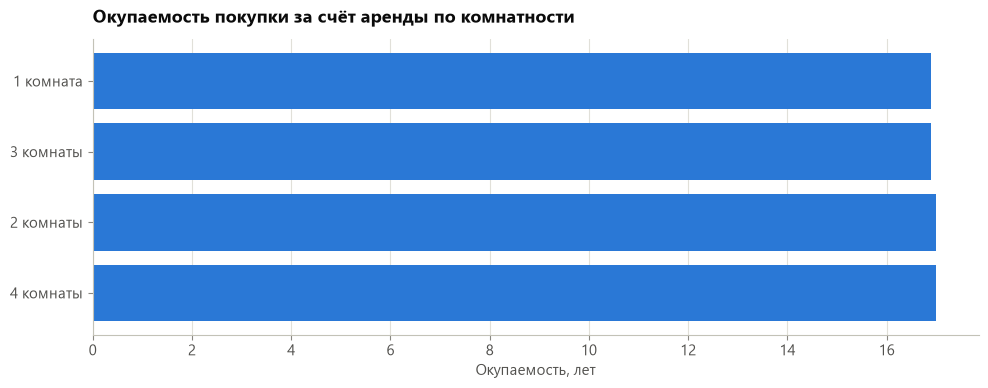

In [36]:
from src.investment import (
    payback_by_segment, plot_payback_bars,
    plot_yield_growth_quadrants, composite_ranking,
)

payback_rooms = payback_by_segment(df_secondary, df_rentals, ['rooms'])
print('=== Окупаемость по числу комнат ===')
print(payback_rooms.to_string())

plot_payback_bars(
    payback_rooms,
    {1: '1 комната', 2: '2 комнаты', 3: '3 комнаты', 4: '4 комнаты'},
    'Окупаемость покупки за счёт аренды по комнатности',
)

=== Окупаемость по типу дома ===
               price_sqm  n_sale  rent_sqm  n_rent  Окупаемость, лет  Доходность, % годовых
building_type                                                                              
brick           189100.0    6760     942.5    2798              16.7                   5.98
khrushchev      157200.0    6056     779.0    2442              16.8                   5.95
monolith        197950.0    7672     983.0    3028              16.8                   5.96
panel           168650.0    7994     839.0    3944              16.8                   5.97
modern_panel    182200.0    7731     892.0    2623              17.0                   5.87
stalin          217050.0    2594    1033.5     728              17.5                   5.71


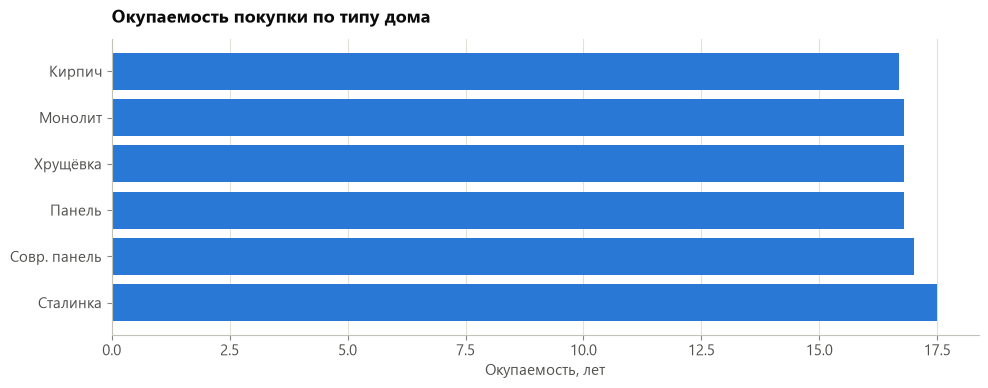

In [37]:
from src.price_factors import BUILDING_TYPE_RU

payback_type = payback_by_segment(df_secondary, df_rentals, ['building_type'])
print('=== Окупаемость по типу дома ===')
print(payback_type.to_string())

plot_payback_bars(payback_type, BUILDING_TYPE_RU, 'Окупаемость покупки по типу дома')

Теперь два признака сразу — тепловая карта окупаемости. Палитра развёрнута: тёмное здесь означает **долгую** окупаемость, то есть плохо для покупателя.

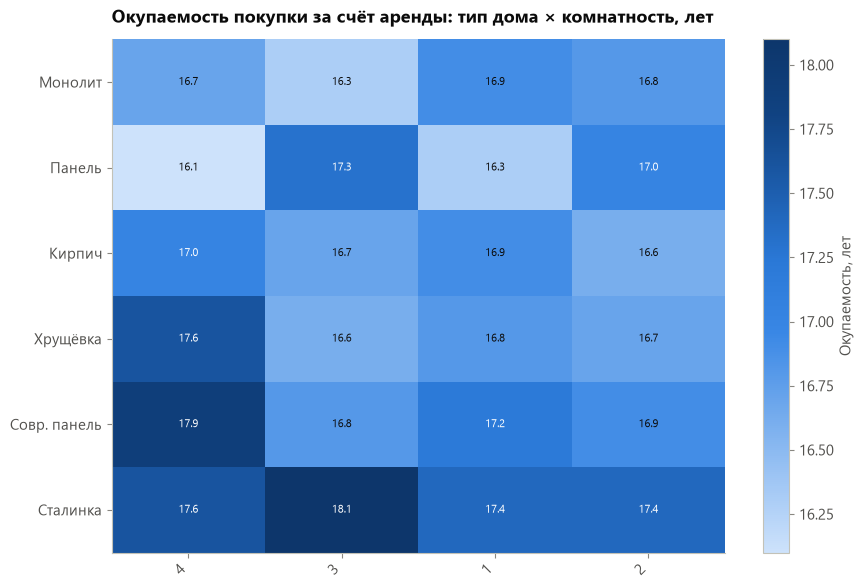

In [38]:
payback_matrix = payback_by_segment(df_secondary, df_rentals, ['building_type', 'rooms'])
heat_payback = payback_matrix['Окупаемость, лет'].unstack()
heat_payback.index = [BUILDING_TYPE_RU.get(i, i) for i in heat_payback.index]
heat_payback = heat_payback.loc[heat_payback.mean(axis=1).sort_values().index]

plot_heatmap(
    heat_payback,
    title='Окупаемость покупки за счёт аренды: тип дома × комнатность, лет',
    cbar_label='Окупаемость, лет',
    fmt='{:.1f}',
    figsize=(9, 6),
)

### Выводы по 8.4.1

**Разбивка почти ничего не изменила — и это сам по себе результат.**

По комнатности разницы нет вообще: окупаемость 16.9-17.0 лет, доходность 5.87-5.92% годовых для всех вариантов от однушки до четырёхкомнатной. Причина видна в исходных числах: и цена за м² (181 200 — 182 600), и арендная ставка за м² (887 — 898) практически не зависят от числа комнат.

Это **противоречит распространённому убеждению**, что маленькие квартиры выгоднее сдавать, потому что метр в них стоит дороже. В этих данных такого эффекта нет.

По типу дома разброс тоже небольшой (16.7-17.5 лет), но здесь есть содержательный вывод:

| Тип дома | Окупаемость | Доходность |
|---|---|---|
| Кирпич | 16.7 лет | 5.98% |
| Панель, монолит, хрущёвка | 16.8 лет | 5.95-5.97% |
| Совр. панель | 17.0 лет | 5.87% |
| **Сталинка** | **17.5 лет** | **5.71%** |

**Сталинка — худший вариант для сдачи.** Причина в разной величине надбавки: по данным 7.3 сталинка стоит на 38.1% дороже хрущёвки при покупке, но сдаётся всего на 32.7% дороже. Престиж дома оплачивается при покупке полностью, а через аренду возвращается не весь.

На тепловой карте это видно точечно: единственная тёмная ячейка — сталинка × 3 комнаты (18.1 года), самое невыгодное сочетание. Самое выгодное — панель × 4 комнаты (16.1 года).

**Общий смысл:** доходность держится около 5.9% практически при любом выборе. Рынок оценивает аренду и продажу согласованно, поэтому комнатность и тип дома на инвестиционную математику почти не влияют — влияет район, что и покажет 8.4.3.

### 8.4.2 Наценка новостроек и льготная ипотека

Проверяем ходовую гипотезу: если по объекту доступна льготная ипотека, застройщик может заложить выгоду покупателя в цену, и такое жильё окажется дороже.

Сразу важная деталь: доля объектов с льготной ипотекой почти одинакова во всех классах (64-67%), поэтому прямое сравнение здесь не искажается перекосом по классам.

In [39]:
subsidy = df_new_builds.groupby('subsidized_mortgage').agg(
    Объявлений=('price_per_sqm', 'size'),
    Медиана_цены=('price_per_sqm', 'median'),
    До_центра_км=('to_center_km', 'median'),
    Доля_новой_Москвы=('is_new_moscow', 'mean'),
).round(2)
subsidy.index = ['Без льготной ипотеки', 'С льготной ипотекой']
print('=== Прямое сравнение ===')
print(subsidy.to_string())

diff = (subsidy.loc['С льготной ипотекой', 'Медиана_цены'] /
        subsidy.loc['Без льготной ипотеки', 'Медиана_цены'] - 1) * 100
print(f"\nРазница в цене: {diff:+.1f}%")

=== Прямое сравнение ===
                      Объявлений  Медиана_цены  До_центра_км  Доля_новой_Москвы
Без льготной ипотеки        2753      244300.0         13.29               0.20
С льготной ипотекой         5247      221900.0         13.69               0.21

Разница в цене: -9.2%


Прямое сравнение может врать из-за географии. Сравним внутри одного округа и класса — так эффект льготной ипотеки отделяется от эффекта локации.

In [40]:
controlled = df_new_builds.pivot_table(
    index='okrug', columns='subsidized_mortgage',
    values='price_per_sqm', aggfunc='median',
)
controlled.columns = ['Без льготы', 'С льготой']
controlled['Разница, %'] = ((controlled['С льготой'] / controlled['Без льготы'] - 1) * 100).round(1)
print('=== Внутри округа ===')
print(controlled.round(0).to_string())

by_class = df_new_builds.pivot_table(
    index='complex_class', columns='subsidized_mortgage',
    values='price_per_sqm', aggfunc='median',
)
by_class.columns = ['Без льготы', 'С льготой']
by_class['Разница, %'] = ((by_class['С льготой'] / by_class['Без льготы'] - 1) * 100).round(1)
print('\n=== Внутри класса жилья ===')
print(by_class.round(0).to_string())

=== Внутри округа ===
       Без льготы  С льготой  Разница, %
okrug                                   
CAO      525400.0   477550.0        -9.0
NAO      173100.0   151950.0       -12.0
SAO      280350.0   248850.0       -11.0
SVAO     209000.0   191900.0        -8.0
SZAO     278850.0   263300.0        -6.0
TAO       87650.0    80400.0        -8.0
VAO      228250.0   213200.0        -7.0
YuAO     229950.0   222200.0        -3.0
YuZAO    301800.0   290000.0        -4.0
ZAO      314900.0   307500.0        -2.0
ZelAO    130900.0   119650.0        -9.0

=== Внутри класса жилья ===
               Без льготы  С льготой  Разница, %
complex_class                                   
business         332900.0   313100.0        -6.0
comfort          234200.0   213500.0        -9.0
economy          196600.0   180450.0        -8.0
premium          448100.0   424100.0        -5.0


In [41]:
conn = sqlite3.connect(str(PROCESSED_DIR / 'moscow_realty.db'))
premium_view = pd.read_sql_query('SELECT * FROM v_new_build_premium', conn)
conn.close()

subsidy_share = df_new_builds.groupby('district').agg(
    subsidy_share=('subsidized_mortgage', 'mean'),
    n=('subsidized_mortgage', 'size'),
)
linked = premium_view.set_index('district').join(subsidy_share, how='inner')
linked = linked[linked['n'] >= 20]

print(f"Районов для сравнения: {len(linked)}")
print(f"Корреляция доли льготной ипотеки с наценкой новостроек: "
      f"{linked['subsidy_share'].corr(linked['premium_pct']):+.3f}")
print(f"\nКорреляция ставки на момент размещения с ценой: "
      f"{df_new_builds['mortgage_rate_at_listing'].corr(df_new_builds['price_per_sqm']):+.3f}")

Районов для сравнения: 89
Корреляция доли льготной ипотеки с наценкой новостроек: -0.172

Корреляция ставки на момент размещения с ценой: +0.116


### Выводы по 8.4.2

**Гипотеза не подтвердилась, причём результат оказался противоположным ожидаемому.**

Предполагалось, что застройщик закладывает выгоду от льготной ипотеки в цену, и такие объекты будут дороже. На деле объекты с льготной ипотекой стоят **на 9.2% дешевле**.

И это не артефакт географии или класса — эффект держится внутри каждой группы:

| Разрез | Диапазон разницы |
|---|---|
| Внутри округа (11 округов) | от −2% (ЗАО) до −12% (НАО) |
| Внутри класса жилья | от −5% (премиум) до −9% (комфорт) |

Ни одного исключения: во всех 11 округах и во всех 4 классах объекты с льготой дешевле.

**Объяснение, скорее всего, в обратной причинности.** Не льгота делает жильё дороже, а наоборот — программы льготной ипотеки обычно имеют потолок по сумме кредита, поэтому доступны именно на более дешёвых объектах. Мы наблюдаем не влияние льготы на цену, а отбор объектов по цене для льготы.

Косвенно это же подтверждает связь на уровне районов: корреляция доли льготных объектов с наценкой новостроек над вторичкой составляет **−0.172** — слабая, но в ту же сторону.

**Отдельно про ставку на момент размещения.** Её корреляция с ценой вышла **+0.116**, то есть формально «выше ставка — выше цена», что противоречит здравому смыслу. Это классическая ложная корреляция через время: за 2020-2026 годы и цены выросли на 55%, и ставка поднялась с 4.25% до 21%. Общий тренд по времени создаёт связь там, где причинной зависимости нет. Настоящее соотношение мы уже измерили правильно в 8.2.1 — там оно отрицательное (−0.511) и проявляется на приростах цены с лагом в месяц, а не на уровнях.

### 8.4.3 Сводный рейтинг районов

Собираем район как инвестицию по двум показателям сразу:

- **доходность аренды** (% годовых) — сколько приносит сдача, обратная величина окупаемости
- **рост цены за 24 месяца** (%) — насколько дорожал сам актив

Показатели приводятся к общей шкале 0-1 и складываются с равными весами. **Веса — это решение, а не расчёт:** поставив рост важнее доходности, получишь другой топ. Поэтому рейтинг всегда нужно читать вместе с весами, на которых он построен.

In [42]:
conn = sqlite3.connect(str(PROCESSED_DIR / 'moscow_realty.db'))
payback_view = pd.read_sql_query('SELECT * FROM v_payback_period', conn)
conn.close()

# доходность аренды из окупаемости
payback_view['rental_yield'] = (100 / payback_view['payback_years']).round(2)

# рост цены за последние 24 месяца по официальным данным
last_date = df_monthly['year_month'].max()
start_date = last_date - pd.DateOffset(months=24)

growth_by_district = df_monthly[df_monthly['year_month'].isin([start_date, last_date])]
growth_by_district = growth_by_district.pivot_table(
    index='district', columns='year_month', values='secondary_price_per_sqm'
)
growth_by_district['growth_24m'] = (
    (growth_by_district[last_date] / growth_by_district[start_date] - 1) * 100
).round(2)

ranking_data = payback_view.set_index('district')[['okrug', 'payback_years', 'rental_yield']]
ranking_data = ranking_data.join(growth_by_district[['growth_24m']], how='inner')

print(f"Районов в рейтинге: {len(ranking_data)}")
print(f"Доходность аренды: от {ranking_data['rental_yield'].min():.2f}% до {ranking_data['rental_yield'].max():.2f}%")
print(f"Рост за 24 мес: от {ranking_data['growth_24m'].min():.1f}% до {ranking_data['growth_24m'].max():.1f}%")
print(f"Корреляция доходности и роста: {ranking_data['rental_yield'].corr(ranking_data['growth_24m']):+.3f}")

Районов в рейтинге: 107
Доходность аренды: от 5.15% до 6.76%
Рост за 24 мес: от -6.5% до 11.0%
Корреляция доходности и роста: +0.136


In [43]:
ranked = composite_ranking(ranking_data, ['rental_yield', 'growth_24m'])

print('=== Топ-12 районов по сводному баллу ===')
print(ranked.head(12).to_string())
print('\n=== Худшие 8 ===')
print(ranked.tail(8).to_string())

=== Топ-12 районов по сводному баллу ===
                  okrug  payback_years  rental_yield  growth_24m  Балл
district                                                              
Molzhaninovsky      SAO           14.8          6.76        8.91  94.0
Tsaritsyno         YuAO           15.8          6.33       11.02  86.6
Yuzhnoye Butovo   YuZAO           15.2          6.58        2.58  70.3
Novogireyevo        VAO           16.2          6.17        6.75  69.5
Severnoye Butovo  YuZAO           15.9          6.29        4.84  67.7
Dmitrovsky          SAO           15.9          6.29        3.57  64.1
Vnukovo             ZAO           15.3          6.54        0.81  64.0
Altufyevsky        SVAO           16.6          6.02        6.44  63.9
Levoberezhny        SAO           16.7          5.99        6.26  62.5
Brateyevo          YuAO           16.4          6.10        4.15  59.9
Severny            SVAO           15.2          6.58       -1.08  59.8
Solntsevo           ZAO           15

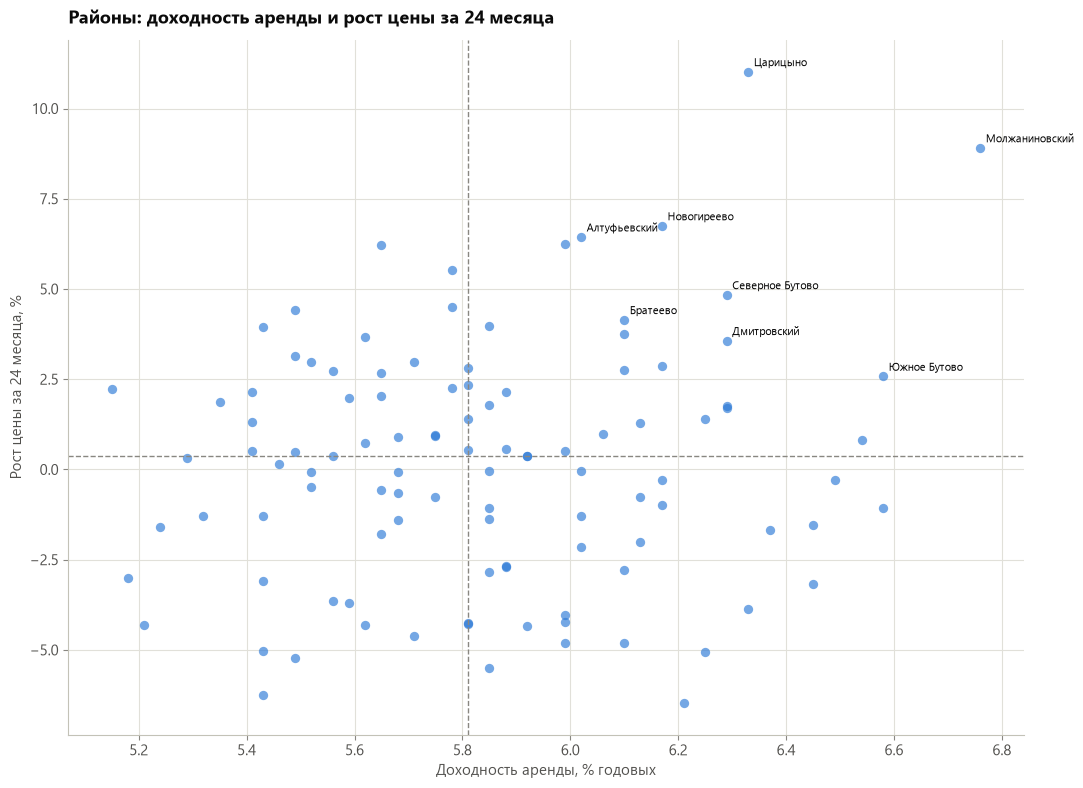

In [44]:
from src.names import DISTRICT_NAMES_RU

plot_data = ranked.reset_index()
plot_data['district'] = plot_data['district'].map(DISTRICT_NAMES_RU)
plot_yield_growth_quadrants(
    plot_data, 'rental_yield', 'growth_24m', 'district',
    'Районы: доходность аренды и рост цены за 24 месяца',
)

### Выводы по 8.4.3

**Главный вывод переворачивает всё, что мы видели в проекте до этого.**

Весь анализ до сих пор говорил одно: центр — это дорого, престижно, премиально. С точки зрения **инвестиций** картина ровно обратная — центр оказался худшим вариантом.

**Топ-5 районов по сводному баллу:**

| Район | Округ | Доходность | Рост за 24 мес | Балл |
|---|---|---|---|---|
| Molzhaninovsky | САО | 6.76% | +8.9% | 94.0 |
| Tsaritsyno | ЮАО | 6.33% | +11.0% | 86.6 |
| Yuzhnoye Butovo | ЮЗАО | 6.58% | +2.6% | 70.3 |
| Novogireyevo | ВАО | 6.17% | +6.8% | 69.5 |
| Severnoye Butovo | ЮЗАО | 6.29% | +4.8% | 67.7 |

**Худшие 5:**

| Район | Округ | Доходность | Рост за 24 мес | Балл |
|---|---|---|---|---|
| Maryina Roshcha | СВАО | 5.21% | −4.3% | 8.0 |
| Krasnoselsky | ЦАО | 5.43% | −6.3% | 9.3 |
| Yakimanka | ЦАО | 5.18% | −3.0% | 10.9 |
| Khoroshyovsky | САО | 5.43% | −5.0% | 12.8 |
| Sokolniki | ВАО | 5.49% | −5.2% | 14.1 |

В топе — исключительно окраины, в хвосте — четыре района ЦАО из восьми худших. Экономически это логично: дорогая недвижимость в центре даёт меньшую арендную доходность (цена растёт быстрее аренды), а последние два года ещё и дешевеет. Премия за центр оплачивается покупателем, но не возвращается ни через аренду, ни через рост цены.

**Доходность и рост почти не связаны между собой** — корреляция +0.136. То есть выбирать между «сдавать» и «ждать подорожания» не приходится: это два независимых свойства района, и есть районы, где хорошо и то, и другое (правый верхний квадрант графика).

**Три оговорки, без которых рейтингом пользоваться нельзя:**

1. **Веса выбраны произвольно.** Доходность и рост взяты с равными весами. Если считать рост важнее, наверх поднимется Царицыно с его +11%; если важнее стабильный доход — Молжаниновский. Рейтинг всегда следует читать вместе с весами, на которых он построен
2. **Доходность валовая.** Налоги, простои между арендаторами и расходы на содержание не учитывались — реальная доходность будет заметно ниже 5-6%
3. **Рост за 24 месяца — это прошлое, а не прогноз.** Район, который дорожал два года, не обязан дорожать дальше; в 8.2.3 мы как раз видели, что рынок в целом вышел на плато

## 8.5 Аномалии и качество данных

### 8.5.1 «Дешёвая категория в премиум-сегменте» на аренде и вторичке

В `data_clean_new_builds.ipynb` мы разбирали странность: объекты economy-класса попадали в премиум-сегмент по цене, и оказалось, что дело в локации — эконом в центре дороже премиума на окраине.

У вторички и аренды колонки `complex_class` нет, но есть прямой аналог — **тип дома**. Хрущёвка это самый дешёвый тип по данным 7.3, и вопрос тот же: попадают ли хрущёвки в премиум-сегмент, и если да, то почему.

In [45]:
from src.price_factors import BUILDING_TYPE_RU

for label, df in [('Вторичка', df_secondary), ('Аренда', df_rentals)]:
    table = pd.crosstab(df['building_type'], df['is_premium'])
    table.columns = ['Обычных', 'Премиум']
    table['Доля премиума, %'] = (table['Премиум'] / (table['Премиум'] + table['Обычных']) * 100).round(1)
    table.index = [BUILDING_TYPE_RU.get(i, i) for i in table.index]
    table = table.sort_values('Доля премиума, %', ascending=False)
    print(f'=== {label} ===')
    print(table.to_string())
    print()

=== Вторичка ===
              Обычных  Премиум  Доля премиума, %
Сталинка         3162      353              10.0
Монолит          9335      662               6.6
Кирпич           8274      562               6.4
Совр. панель     9462      519               5.2
Панель           9728      415               4.1
Хрущёвка         7324      204               2.7

=== Аренда ===
              Обычных  Премиум  Доля премиума, %
Сталинка          876       99              10.2
Монолит          3694      264               6.7
Кирпич           3433      217               5.9
Совр. панель     3201      173               5.1
Панель           4777      190               3.8
Хрущёвка         2991       85               2.8



Хрущёвки в премиуме есть. Теперь главный вопрос — чем они отличаются от обычных хрущёвок.

In [46]:
for label, df, price_col in [
    ('Вторичка', df_secondary, 'price_per_sqm'),
    ('Аренда', df_rentals, 'rent_per_sqm'),
]:
    kh = df[df['building_type'] == 'khrushchev']
    compare = kh.groupby('is_premium').agg(
        Объявлений=(price_col, 'size'),
        Медиана_цены=(price_col, 'median'),
        До_центра_км=('to_center_km', 'median'),
        До_метро_мин=('metro_distance_min', 'median'),
        Площадь=('total_area', 'median'),
    ).round(1)
    compare.index = ['Обычные хрущёвки', 'Премиум-хрущёвки']
    print(f'=== {label} ===')
    print(compare.to_string())
    ratio = compare.loc['Обычные хрущёвки', 'До_центра_км'] / compare.loc['Премиум-хрущёвки', 'До_центра_км']
    print(f'Обычные хрущёвки дальше от центра в {ratio:.1f} раза\n')

=== Вторичка ===
                  Объявлений  Медиана_цены  До_центра_км  До_метро_мин  Площадь
Обычные хрущёвки        7324      143100.0          13.3          40.5     65.3
Премиум-хрущёвки         204      472900.0           2.8          14.0     64.2
Обычные хрущёвки дальше от центра в 4.8 раза

=== Аренда ===
                  Объявлений  Медиана_цены  До_центра_км  До_метро_мин  Площадь
Обычные хрущёвки        2991         714.0          13.5         112.0     54.0
Премиум-хрущёвки          85        2134.0           2.9          13.0     53.5
Обычные хрущёвки дальше от центра в 4.7 раза



In [47]:
# где именно расположены премиум-хрущёвки
kh_premium = df_secondary[(df_secondary['building_type'] == 'khrushchev') & df_secondary['is_premium']]
by_okrug = kh_premium['okrug'].value_counts()
print('=== Премиум-хрущёвки по округам (вторичка) ===')
print(by_okrug.to_string())
print(f"\nДоля ЦАО среди премиум-хрущёвок: {(kh_premium['okrug'] == 'CAO').mean() * 100:.1f}%")
print(f"Доля ЦАО среди всех хрущёвок:      "
      f"{(df_secondary[df_secondary['building_type'] == 'khrushchev']['okrug'] == 'CAO').mean() * 100:.1f}%")

=== Премиум-хрущёвки по округам (вторичка) ===
okrug
CAO      198
ZAO        3
SAO        1
SZAO       1
YuZAO      1

Доля ЦАО среди премиум-хрущёвок: 97.1%
Доля ЦАО среди всех хрущёвок:      8.0%


### Выводы по 8.5.1

**Методика из new_builds полностью подтвердилась и на вторичке, и на аренде.**

Доля премиума по типам домов повторяет ценовой рейтинг из 7.3 один в один, причём в обоих сегментах независимо:

| Тип дома | Премиум, вторичка | Премиум, аренда |
|---|---|---|
| Сталинка | 10.0% | 10.2% |
| Монолит | 6.6% | 6.7% |
| Кирпич | 6.4% | 5.9% |
| Совр. панель | 5.2% | 5.1% |
| Панель | 4.1% | 3.8% |
| **Хрущёвка** | **2.7%** | **2.8%** |

Хрущёвок в премиуме мало, но они есть — 204 на вторичке и 85 в аренде. И объясняются они ровно тем же, что и economy-класс в новостройках:

| | Обычные хрущёвки | Премиум-хрущёвки |
|---|---|---|
| Медиана цены | 143 100 | 472 900 |
| До центра | 13.3 км | **2.8 км** |
| До метро | 40.5 мин | **14 мин** |
| Площадь | 65.3 м² | 64.2 м² |

**Ключевая деталь — площадь одинаковая** (65.3 против 64.2 м²). То есть премиум-хрущёвки не крупнее и не просторнее обычных, они просто стоят в другом месте: втрое ближе к центру и почти втрое ближе к метро.

Проверка по географии добивает окончательно: **97.1% премиум-хрущёвок находятся в ЦАО**, при том что в ЦАО расположено всего 8.0% всех хрущёвок вообще. Концентрация в 12 раз.

**Вывод:** «дешёвая категория в премиум-сегменте» — это не ошибка данных и не аномалия, а один и тот же механизм во всех трёх таблицах. Локация перебивает категорию жилья настолько, что худший тип дома в центре стоит дороже лучшего типа на окраине. Ровно этот же вывод мы получили независимо в 7.4 (класс новостроек), 8.1.2 (коэффициенты регрессии), 8.1.3 (важность признаков) и 8.3.1 (кластеризация).

### 8.5.2 Устойчивость порога премиум-сегмента во времени

> **Читать как есть: этот пункт написан до исправления и намеренно не переписан.** Здесь ошибка находится, в 8.5.3 сразу за ним — исправляется. Проверки ниже считаются прямо из цен и не зависят от колонки `is_premium`, поэтому после пересчёта пайплайна они воспроизводятся в точности в том же виде.

Порог премиума в проекте на этот момент считался **один раз на всех данных сразу**: Q3 + 1.5 × IQR по всей таблице. Но объявления охватывают 2020-2026 годы, а цены за этот период выросли на 55% (мы это измерили в 8.2.1).

Отсюда вопрос, который может подорвать всё, что построено на `is_premium`: не получается ли, что объявление попадает в премиум не потому, что жильё дорогое, а просто потому, что оно размещено позже, когда рынок уже подорожал?

Проверяем прямо: считаем для каждого года собственный порог и сравниваем две доли премиума — по общему порогу и по порогу самого года.

In [48]:
from src.segmentation import premium_threshold, threshold_stability, plot_threshold_stability

df_secondary['year'] = pd.to_datetime(df_secondary['date_posted']).dt.year

stability = threshold_stability(df_secondary, 'price_per_sqm', 'year')
print(f"Общий порог по всем данным: {stability.attrs['global_threshold']:,} руб/м²".replace(',', ' '))
print()
print(stability.to_string())

Общий порог по всем данным: 414 250 руб/м²

        Объявлений  Порог периода  Премиум по общему порогу, %  Премиум по порогу периода, %
Период                                                                                      
2020          7859         318275                          2.0                           5.5
2021          7883         367600                          3.5                           5.3
2022          7966         398938                          5.0                           5.6
2023          7964         438262                          6.6                           5.4
2024          7986         458650                          7.6                           5.4
2025          7747         443200                          6.8                           5.4
2026          2595         468000                          8.0                           5.2


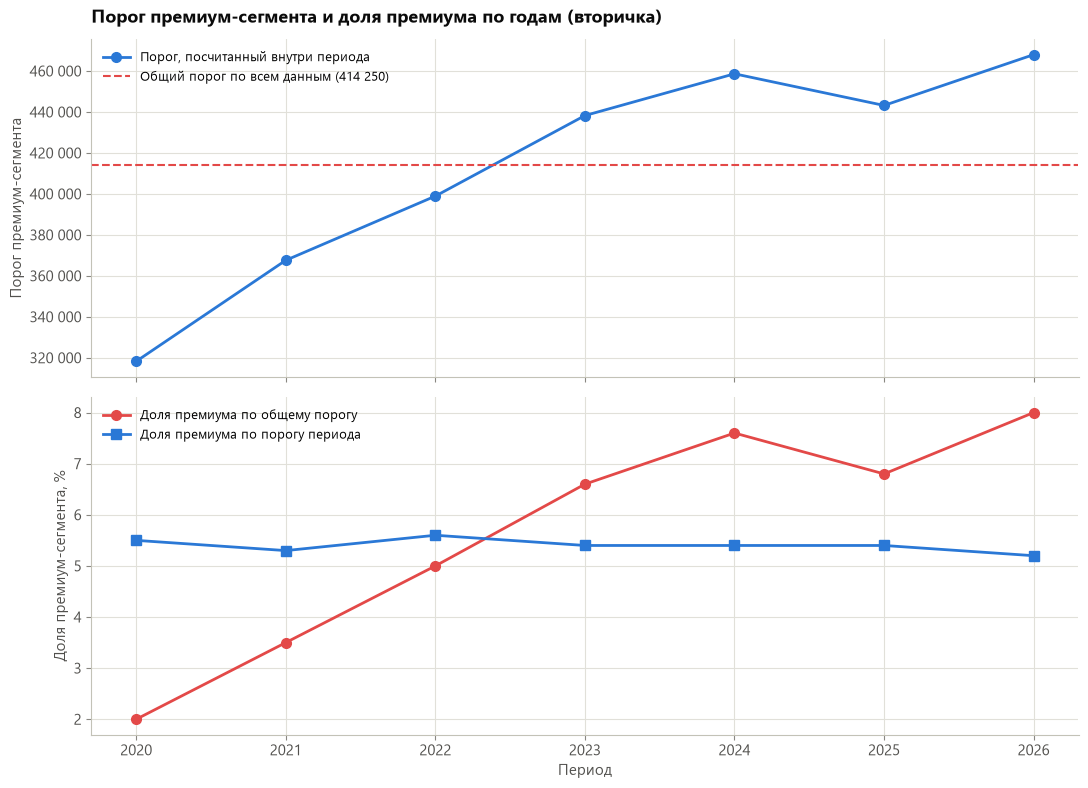

In [49]:
plot_threshold_stability(stability, 'Порог премиум-сегмента и доля премиума по годам (вторичка)')

In [50]:
drift = (stability['Порог периода'].iloc[-1] / stability['Порог периода'].iloc[0] - 1) * 100
share_global = stability['Премиум по общему порогу, %']
share_local = stability['Премиум по порогу периода, %']

print(f"Порог сдвинулся за период на {drift:+.1f}%")
print(f"Доля премиума по общему порогу: от {share_global.min()}% до {share_global.max()}% "
      f"(разница в {share_global.max() / share_global.min():.1f} раза)")
print(f"Доля премиума по порогу периода: от {share_local.min()}% до {share_local.max()}% "
      f"(разница в {share_local.max() / share_local.min():.1f} раза)")

# то же самое для аренды — проверяем, общая ли это проблема
df_rentals['year'] = pd.to_datetime(df_rentals['date_posted']).dt.year
stability_rent = threshold_stability(df_rentals, 'rent_per_sqm', 'year')
print('\n=== Аренда ===')
print(stability_rent.to_string())

Порог сдвинулся за период на +47.0%
Доля премиума по общему порогу: от 2.0% до 8.0% (разница в 4.0 раза)
Доля премиума по порогу периода: от 5.2% до 5.6% (разница в 1.1 раза)

=== Аренда ===
        Объявлений  Порог периода  Премиум по общему порогу, %  Премиум по порогу периода, %
Период                                                                                      
2021          3788           1622                          3.0                           5.3
2022          3869           1734                          4.0                           5.2
2023          3797           1901                          5.4                           5.0
2024          3705           1978                          6.8                           5.6
2025          3643           1969                          5.6                           4.6
2026          1198           1997                          6.3                           5.2


### Выводы по 8.5.2

**Проверка вскрыла настоящую методологическую проблему.**

Порог, посчитанный внутри каждого года, уезжает вместе с рынком — с 318 275 в 2020 году до 468 000 в 2026, то есть **на +47%**. А общий порог зафиксирован на 414 250 и не двигается.

Последствия видны сразу:

| Год | Порог года | Премиум по общему порогу | Премиум по порогу года |
|---|---|---|---|
| 2020 | 318 275 | **2.0%** | 5.5% |
| 2021 | 367 600 | 3.5% | 5.3% |
| 2022 | 398 938 | 5.0% | 5.6% |
| 2023 | 438 262 | 6.6% | 5.4% |
| 2024 | 458 650 | 7.6% | 5.4% |
| 2025 | 443 200 | 6.8% | 5.4% |
| 2026 | 468 000 | **8.0%** | 5.2% |

**Доля премиума по общему порогу выросла с 2.0% до 8.0% — в 4 раза.** По порогу года она стоит на месте: 5.2-5.6%, разброс всего в 1.1 раза.

Это значит, что **`is_premium` частично кодирует не «дорогое жильё», а «объявление размещено позже»**. Объекту 2020 года нужно быть гораздо более выдающимся, чтобы получить метку премиума, чем объекту 2026 года. Та же картина в аренде: 3.0% в 2021 против 6.8% в 2024 по общему порогу, при стабильных 4.6-5.6% по порогу года.

**Насколько это подрывает предыдущие выводы.** Разбираю честно:

- Там, где премиум **исключался** (разделы 7.2, 7.3, 8.1.1, 8.3.3 и другие) — выводы устойчивы. Смещение убирает из выборки чуть больше свежих объявлений, чем старых, но действует одинаково на все сравниваемые группы, поэтому относительные различия между типами домов, ремонтом и округами не меняются
- Там, где премиум был **предметом изучения** (8.1.3) — вывод «премиум определяется локацией» остаётся в силе: `to_center_km` доминировал с огромным отрывом. Но нужно отметить, что среди признаков был `mortgage_rate_at_listing`, а он по сути метка времени, и часть качества классификатора могла идти именно от неё. Вклад был небольшой (0.0067 по перемешиванию против 0.104 у расстояния до центра), так что вывод не переворачивается


### 8.5.3 Исправление: порог премиума считается внутри года

Порог IQR теперь считается отдельно для каждого года публикации, а не один общий на весь период 2020-2026.

| Было | Стало |
|---|---|
| `add_premium_flag(df, price_col)` — один порог Q3 + 1.5 × IQR по всей таблице | `add_premium_flag_by_year(df, price_col, date_col='date_posted')` — свой порог для каждого года |

Старая функция в `src/segmentation.py` не удалена, а помечена как устаревшая — она используется ниже вместе с новой, чтобы напрямую сравнить их результат.

Ниже — проверка, что исправление сработало.

In [51]:
# is_premium в data/processed/ уже посчитан новым методом — проверяем, ушёл ли дрейф по годам
for label, df in [
    ('Аренда', df_rentals),
    ('Вторичка', df_secondary),
    ('Новостройки', df_new_builds),
]:
    year = pd.to_datetime(df['date_posted']).dt.year
    by_year = df.groupby(year)['is_premium'].mean() * 100
    print(f'=== {label} ===')
    print('  ' + '  '.join(f'{y}: {v:.1f}%' for y, v in by_year.items()))
    print(f'  Разброс по годам: {by_year.min():.1f}-{by_year.max():.1f}% '
          f'(в {by_year.max() / by_year.min():.1f} раза), всего премиума {df["is_premium"].mean() * 100:.1f}%\n')

=== Аренда ===
  2021: 5.3%  2022: 5.2%  2023: 5.0%  2024: 5.6%  2025: 4.6%  2026: 5.2%
  Разброс по годам: 4.6-5.6% (в 1.2 раза), всего премиума 5.1%

=== Вторичка ===
  2020: 5.5%  2021: 5.3%  2022: 5.6%  2023: 5.4%  2024: 5.4%  2025: 5.4%  2026: 5.2%
  Разброс по годам: 5.2-5.6% (в 1.1 раза), всего премиума 5.4%

=== Новостройки ===
  2021: 4.1%  2022: 3.2%  2023: 2.8%  2024: 3.5%  2025: 4.4%  2026: 6.4%
  Разброс по годам: 2.8-6.4% (в 2.2 раза), всего премиума 3.8%



Для сравнения — та же величина по старому методу лежит в таблице 8.5.2: 2.0% в 2020 против 8.0% в 2026, разброс в 4 раза.

Теперь посмотрим, сколько объявлений в итоге сменили метку.

In [52]:
from src.segmentation import compare_premium_methods

for label, df, price_col in [
    ('Аренда', df_rentals, 'rent_per_sqm'),
    ('Вторичка', df_secondary, 'price_per_sqm'),
    ('Новостройки', df_new_builds, 'price_per_sqm'),
]:
    print(f'=========== {label} ===========')
    compare_premium_methods(df, price_col)
    print()

=========== Аренда ===========
Общий порог по всей выборке: 1 872
Премиум по общему порогу:  1001 (5.0%)
Премиум по порогу года:    1028 (5.1%)

Сменили метку: 243 объявлений из 20000 (1.2%)
  были премиумом, перестали: 108
  не были премиумом, стали:  135

=========== Вторичка ===========
Общий порог по всей выборке: 414 250
Премиум по общему порогу:  2696 (5.4%)
Премиум по порогу года:    2715 (5.4%)

Сменили метку: 909 объявлений из 50000 (1.8%)
  были премиумом, перестали: 445
  не были премиумом, стали:  464

=========== Новостройки ===========
Общий порог по всей выборке: 538 900
Премиум по общему порогу:  291 (3.6%)
Премиум по порогу года:    300 (3.8%)

Сменили метку: 117 объявлений из 8000 (1.5%)
  были премиумом, перестали: 54
  не были премиумом, стали:  63



И самое важное — насколько исправление сдвинуло сами выводы. Берём находку 8.5.1 (премиум-хрущёвки) и пересчитываем её обоими способами.

In [53]:
from src.segmentation import premium_threshold

# восстанавливаем старый флаг, чтобы сравнить выводы 8.5.1 до и после исправления
old_flag = df_secondary['price_per_sqm'] >= premium_threshold(df_secondary['price_per_sqm'])
kh = df_secondary['building_type'] == 'khrushchev'

rows = []
for label, flag in [('Старый метод (общий порог)', old_flag), ('Новый метод (порог года)', df_secondary['is_premium'])]:
    kh_prem = df_secondary[kh & flag]
    rows.append({
        'Метод': label,
        'Премиум-хрущёвок': len(kh_prem),
        'Доля ЦАО среди них, %': round((kh_prem['okrug'] == 'CAO').mean() * 100, 1),
        'Медиана цены': round(kh_prem['price_per_sqm'].median()),
        'До центра, км': round(kh_prem['to_center_km'].median(), 1),
        'Площадь, м²': round(kh_prem['total_area'].median(), 1),
    })

print(pd.DataFrame(rows).to_string(index=False))

                     Метод  Премиум-хрущёвок  Доля ЦАО среди них, %  Медиана цены  До центра, км  Площадь, м²
Старый метод (общий порог)               208                   95.2        472100            2.8         64.6
  Новый метод (порог года)               204                   97.1        472900            2.8         64.2


### Выводы по 8.5.3

**Дрейф ушёл.** По вторичке доля премиума теперь держится в диапазоне 5.2-5.6% по годам вместо прежних 2.0-8.0% — разброс сжался с 4 раз до 1.1. По аренде — 4.6-5.6% вместо 3.0-6.8%. `is_premium` больше не путает «дорогое жильё» с «объявление размещено позже».

**Новостройки остаются менее устойчивыми** — доля по годам гуляет в диапазоне 2.8-6.4%. Это не остаток прежней ошибки: при 1 500 объявлений в год IQR-порог заметно чувствительнее к форме правого хвоста, чем при 8 000 у вторички, — годовые колебания здесь свойство самих данных, а не методики.

**Метку сменили немного объявлений** — 243 в аренде (1.2%), 909 во вторичке (1.8%), 117 в новостройках (1.5%). Общая доля премиума почти не изменилась ни в одном сегменте: поменялся не размер группы, а её состав.

**Находка 8.5.1 про премиум-хрущёвки подтверждается при обоих методах** — таблица выше показывает, что премиум-хрущёвки как были почти целиком сосредоточены в ЦАО, так и остались.

**Что осталось за рамками.** Порог считается по календарному году — для объявления, размещённого в декабре, «своё время» включает и январь того же года. Более точным было бы скользящее окно (например, 12 месяцев назад от даты объявления), но при годовом росте цен 5-8% выигрыш от него небольшой, а год проще объяснить и воспроизвести.

## 8.6 Статистическая проверка значимости различий

До сих пор все различия мы оценивали на глаз по медианам: «Старая Москва дороже Новой в 2.5 раза», «сталинка дороже хрущёвки на 38%». Пора проверить это формально.

**Какой критерий берём и почему.** Цены распределены сильно несимметрично, с длинным правым хвостом — мы это видели на боксплотах ещё в разделе 2. Классический t-критерий требует нормальности распределения, поэтому здесь не подходит. Берём **критерий Манна-Уитни**: он работает с рангами, никаких предположений о форме распределения не делает и сравнивает распределения целиком.

**Почему одного p-value мало.** У нас десятки тысяч наблюдений. На таких выборках статистически значимым становится **любое** различие, даже ничтожное — p-value покажет «значимо» и для разницы в 30%, и для разницы в 0.5%. Поэтому рядом обязательно считаем **размер эффекта** (ранговая бисериальная корреляция): p-value отвечает на вопрос «различие реально или это случайность?», а размер эффекта — «а оно вообще большое?».

In [54]:
from src.stats_tests import compare_groups, comparison_table

results = []

# 1. Старая и Новая Москва — главное сравнение проекта
results.append(compare_groups(
    df_secondary[~df_secondary['is_new_moscow']]['price_per_sqm'],
    df_secondary[df_secondary['is_new_moscow']]['price_per_sqm'],
    'Старая', 'Новая', 'Старая / Новая Москва (вторичка)',
))

# 2. Сталинка и хрущёвка — вывод из 7.3
clean = df_secondary[~df_secondary['is_premium'] & ~df_secondary['is_new_moscow']]
results.append(compare_groups(
    clean[clean['building_type'] == 'stalin']['price_per_sqm'],
    clean[clean['building_type'] == 'khrushchev']['price_per_sqm'],
    'Сталинка', 'Хрущёвка', 'Сталинка / хрущёвка (вторичка)',
))

# 3. Евроремонт и без ремонта — вывод из 7.2
clean_rent = df_rentals[~df_rentals['is_premium'] & ~df_rentals['is_new_moscow']]
results.append(compare_groups(
    clean_rent[clean_rent['renovation'] == 'euro']['rent_per_sqm'],
    clean_rent[clean_rent['renovation'] == 'no_renovation']['rent_per_sqm'],
    'Евро', 'Без ремонта', 'Евроремонт / без ремонта (аренда)',
))

# 4. Животные — самый слабый эффект из найденных (−2.5% в 7.2)
results.append(compare_groups(
    clean_rent[clean_rent['pets_allowed']]['rent_per_sqm'],
    clean_rent[~clean_rent['pets_allowed']]['rent_per_sqm'],
    'Можно', 'Нельзя', 'Животные разрешены / запрещены (аренда)',
))

print(comparison_table(results).to_string(index=False))

                              Сравнение  Разница медиан, %   p-value Значимо (p<0.05)  Размер эффекта           Оценка
       Старая / Новая Москва (вторичка)              152.0  < 1e-300               да           0.927          большой
         Сталинка / хрущёвка (вторичка)               38.1 3.47e-244               да           0.452          средний
      Евроремонт / без ремонта (аренда)               25.3 1.96e-115               да           0.375          средний
Животные разрешены / запрещены (аренда)               -2.5  1.21e-05               да           0.044 пренебрежимо мал


Отдельно посмотрим на пару «животные разрешены / запрещены» подробнее — это самый показательный случай расхождения между «значимо» и «важно».

In [55]:
pets = results[3]
print(f"Разница медиан: {pets['Разница, %']}%")
print(f"p-value: {pets['p-value']:.2e} — формально различие значимо")
print(f"Размер эффекта: {pets['Размер эффекта']} ({pets['Оценка эффекта']})")
print(f"Объектов в группах: {pets['n (Можно)']:,} и {pets['n (Нельзя)']:,}".replace(',', ' '))

print('\nДля сравнения, самый сильный эффект из проверенных:')
moscow = results[0]
print(f"  {moscow['Сравнение']}: разница {moscow['Разница, %']}%, "
      f"размер эффекта {moscow['Размер эффекта']} ({moscow['Оценка эффекта']})")

Разница медиан: -2.5%
p-value: 1.21e-05 — формально различие значимо
Размер эффекта: 0.044 (пренебрежимо мал)
Объектов в группах: 4 745 и 10 818

Для сравнения, самый сильный эффект из проверенных:
  Старая / Новая Москва (вторичка): разница 152.0%, размер эффекта 0.927 (большой)


### Выводы по 8.6

**Все находки проекта прошли формальную проверку, но с очень разным весом.**

| Сравнение | Разница медиан | p-value | Размер эффекта | Оценка |
|---|---|---|---|---|
| Старая / Новая Москва | +152.0% | < 1e-300 | 0.927 | большой |
| Сталинка / хрущёвка | +38.1% | 3.5e-244 | 0.452 | средний |
| Евроремонт / без ремонта | +25.3% | 2.0e-115 | 0.375 | средний |
| Животные разрешены / нет | −2.5% | 1.2e-05 | **0.044** | **пренебрежимо мал** |

**Три главных вывода проекта подтвердились содержательно.** Разделение на Старую и Новую Москву — эффект 0.927, это практически максимум возможного: распределения почти не пересекаются. Надбавки за тип дома и за ремонт — средние по величине эффекты, то есть реальные и заметные, но не абсолютные.

**А вот четвёртая строка — главный урок этого пункта.** Разница по животным составляет −2.5%, p-value равно 0.000012, то есть формально различие **статистически значимо**. Если остановиться на p-value, можно было бы объявить открытие. Но размер эффекта — 0.044, это пренебрежимо мало: распределения почти полностью накладываются друг на друга.

Значимость здесь взялась исключительно из объёма выборки — 4 745 против 10 818 наблюдений. На таких числах даже разница в доли процента даст «значимый» p-value.

**Практический вывод:** p-value отвечает только на вопрос «различие не случайно?». Вопрос «а оно вообще большое?» — это уже размер эффекта, и без него p-value легко превращается в способ выдать шум за находку. Заодно это подтверждает осторожность, с которой мы трактовали эффект животных ещё в 7.2: там я предположил, что это не «скидка за питомцев», а побочный эффект. Теперь видно, что обсуждать там нечего вовсе.

## 8.7 Сравнение распределений цены по трём сегментам

Проблема очевидна: аренда измеряется сотнями рублей за м² в месяц, а продажа — сотнями тысяч за м². На одной оси их не покажешь.

Решение — **нормировать каждый сегмент на его собственную медиану**. Тогда все три распределения оказываются вокруг 1.0, и сравнивается уже не уровень цен, а **форма**: насколько широко разбросаны цены внутри сегмента, насколько длинный у него правый хвост, насколько он симметричен.

In [56]:
from src.stats_tests import distribution_shape, plot_normalized_distributions, plot_normalized_boxplots

segments = {
    'Аренда': df_rentals['rent_per_sqm'],
    'Вторичка': df_secondary['price_per_sqm'],
    'Новостройки': df_new_builds['price_per_sqm'],
}

shape = pd.DataFrame([distribution_shape(s, label) for label, s in segments.items()])
print(shape.to_string(index=False))

    Сегмент  Объектов  Медиана  Разброс IQR / медиана  P90 / P10  Коэф. вариации  Асимметрия
     Аренда     20000    845.0                  0.581       3.45           0.508        1.59
   Вторичка     50000 170400.0                  0.684       4.17           0.579        1.69
Новостройки      8000 229650.0                  0.639       3.82           0.493        1.00


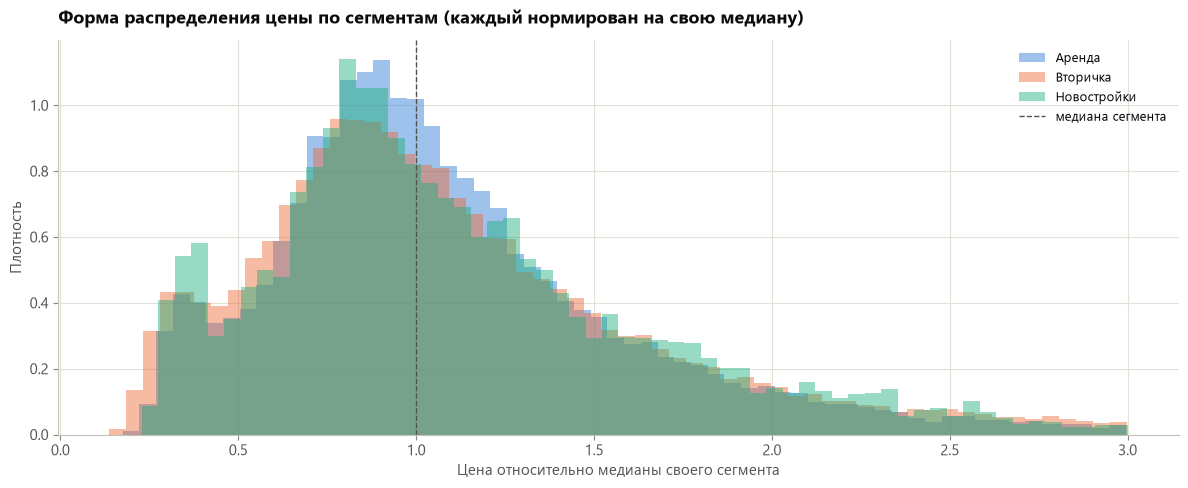

In [57]:
plot_normalized_distributions(
    segments,
    'Форма распределения цены по сегментам (каждый нормирован на свою медиану)',
)

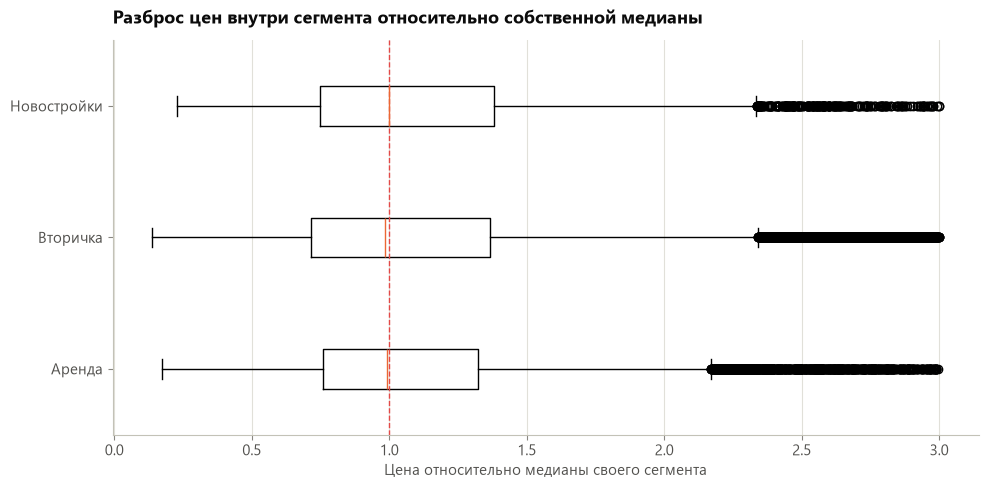

In [58]:
plot_normalized_boxplots(
    segments,
    'Разброс цен внутри сегмента относительно собственной медианы',
)

=== Без премиума и Новой Москвы ===
    Сегмент  Объектов  Медиана  Разброс IQR / медиана  P90 / P10  Коэф. вариации  Асимметрия
     Аренда     15563    897.0                  0.458       2.32           0.325        0.85
   Вторичка     38807 182300.0                  0.534       2.59           0.374        0.93
Новостройки      6062 252400.0                  0.524       2.49           0.354        0.86


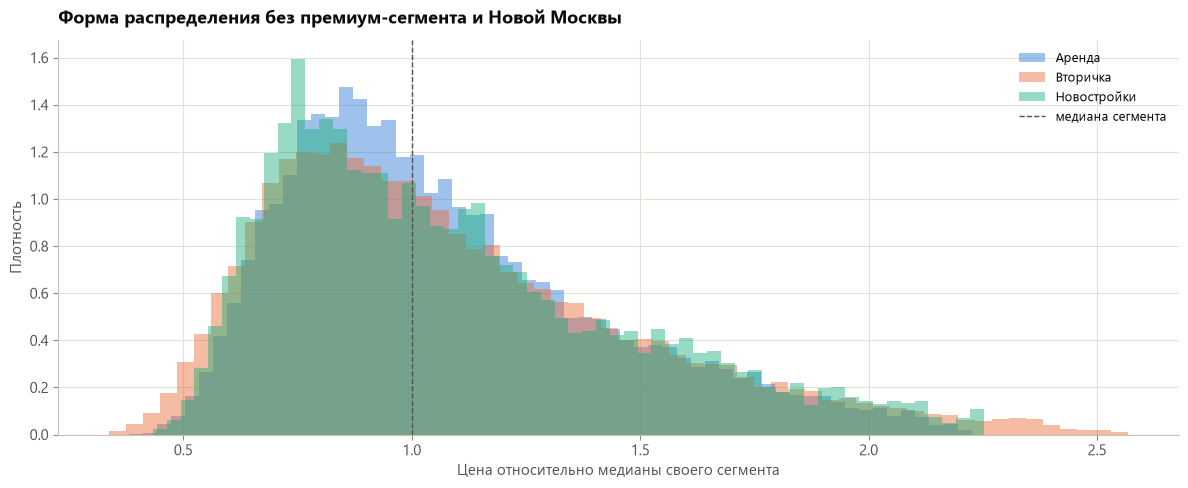

In [59]:
# то же самое, но без премиума и Новой Москвы — проверяем, что задаёт форму хвоста
segments_clean = {
    'Аренда': df_rentals[~df_rentals['is_premium'] & ~df_rentals['is_new_moscow']]['rent_per_sqm'],
    'Вторичка': df_secondary[~df_secondary['is_premium'] & ~df_secondary['is_new_moscow']]['price_per_sqm'],
    'Новостройки': df_new_builds[~df_new_builds['is_premium'] & ~df_new_builds['is_new_moscow']]['price_per_sqm'],
}

shape_clean = pd.DataFrame([distribution_shape(s, label) for label, s in segments_clean.items()])
print('=== Без премиума и Новой Москвы ===')
print(shape_clean.to_string(index=False))

plot_normalized_distributions(
    segments_clean,
    'Форма распределения без премиум-сегмента и Новой Москвы',
)

### Выводы по 8.7

**Сравнивать сегменты в рублях бессмысленно** — аренда измеряется сотнями рублей, продажа сотнями тысяч. Поэтому каждый сегмент нормирован на собственную медиану, и сравнивается форма распределения, а не уровень цен.

**На полных данных сегменты различаются:**

| Сегмент | IQR / медиана | P90 / P10 | Асимметрия |
|---|---|---|---|
| Аренда | 0.581 | 3.45 | 1.59 |
| Вторичка | **0.684** | **4.17** | **1.69** |
| Новостройки | 0.639 | 3.82 | 1.00 |

Вторичка — самый разнородный сегмент: разброс цен внутри неё максимальный, а правый хвост самый длинный. Новостройки — наименее скошенный сегмент (асимметрия 1.00 против 1.69), что логично: застройщик формирует прайс сам, и экстремально дешёвых предложений там почти не бывает.

**А теперь главное.** Если убрать премиум-сегмент и Новую Москву, все три распределения становятся почти **одинаковыми**:

| Сегмент | IQR / медиана | P90 / P10 | Асимметрия |
|---|---|---|---|
| Аренда | 0.458 | 2.32 | **0.85** |
| Вторичка | 0.534 | 2.59 | **0.93** |
| Новостройки | 0.524 | 2.49 | **0.86** |

Разброс и P90/P10 совпадают почти точно, асимметрия сходится в узкий диапазон 0.85-0.93 против 1.00-1.69 на полных данных. На графике кривые ложатся почти одна на другую.

> **Оговорка после исправления 8.5.3.** До пересчёта премиума по годам асимметрия у всех трёх сегментов совпадала до второго знака (0.81 / 0.82 / 0.81), и вывод здесь звучал сильнее — «совпали полностью». Новый порог отрезает у каждого года свой хвост, а не один и тот же уровень цены на всём периоде, поэтому в объединённой выборке остаётся чуть больше межгодового разброса — сильнее всего у вторички (0.93). Это единственное место во всём проекте, где исправление методики **ослабило** формулировку вывода, и я оставляю это здесь, а не прячу: совпадение 0.81 было отчасти артефактом единого порога.

**Что это значит:** вся разница в форме между арендой, вторичкой и новостройками создавалась исключительно двумя подгруппами — премиум-сегментом и Новой Москвой. Как только их убрать, «обычный» рынок ведёт себя одинаково во всех трёх сегментах, независимо от того, снимают жильё или покупают.

**Ещё одна деталь видна на первом графике.** У полных данных заметен левый горб в районе 0.3-0.45 от медианы — это не хвост распределения, а отдельная плотность. На втором графике он исчезает полностью. Это визуальный портрет Новой Москвы: она не «дешёвый край» общего рынка, а самостоятельный кластер со своим уровнем цен — ровно то, что мы утверждали в разделе 2 по результатам боксплотов, теперь подтверждено формой распределения.

## 8.8 Новая Москва: окупаемость и наценка новостроек

SQL-представления `v_payback_period` и `v_new_build_premium` считают метрики только по старой Москве (`is_new_moscow = 0`). При сборке витрины данных для дашборда (`src/mart.py`) те же метрики досчитаны по всем 129 районам по той же формуле: на районах старой Москвы результат совпадает с представлениями до последнего знака, добавились 22 района Новой Москвы. И сразу видно различие:

- окупаемость покупки за счёт аренды в Новой Москве короче — медиана по районам 15.0 года против 17.2
- наценка новостроек над вторичкой в том же районе выше — медиана 49.6% против 34.0%

Прежде чем считать это выводом, проверяем три вещи: не случайность ли это, не объясняется ли оно разным составом жилья и есть ли у различия понятный механизм.

In [60]:
import sqlite3
from src.investment import payback_by_segment, gradient_check, plot_price_gradient
from src.stats_tests import compare_groups

conn = sqlite3.connect(PROCESSED_DIR / 'moscow_realty.db')
districts = pd.read_sql('SELECT * FROM mart_districts', conn)
conn.close()

print(districts.groupby('moscow_part')[['payback_years', 'newbuild_premium_pct']].median())

payback_test = compare_groups(
    districts.loc[districts['is_new_moscow'] == 1, 'payback_years'],
    districts.loc[districts['is_new_moscow'] == 0, 'payback_years'],
    'Новая', 'Старая', 'Окупаемость по районам, лет',
)
premium_test = compare_groups(
    districts.loc[districts['is_new_moscow'] == 1, 'newbuild_premium_pct'].dropna(),
    districts.loc[districts['is_new_moscow'] == 0, 'newbuild_premium_pct'].dropna(),
    'Новая', 'Старая', 'Наценка новостроек по районам, %',
)
print()
print(pd.DataFrame([payback_test, premium_test]).to_string(index=False))

               payback_years  newbuild_premium_pct
moscow_part                                       
Новая Москва            15.0                 49.65
Старая Москва           17.2                 34.00

                       Сравнение  n (Новая)  n (Старая)  Медиана (Новая)  Медиана (Старая)  Разница, %      p-value  Размер эффекта Оценка эффекта
     Окупаемость по районам, лет         22         107             15.0              17.2       -12.8 2.171933e-12           0.953        большой
Наценка новостроек по районам, %         20          89             49.6              34.0        46.0 3.846777e-04           0.510        большой


### 8.8.1 Окупаемость

**Проверка по годам.** Если различие устойчивое, оно должно держаться в каждом году отдельно, а не появляться только на объединённых данных. Считаем окупаемость по медианам объявлений, как в 8.4.1, отдельно по годам и частям города.

In [61]:
df_secondary['year'] = pd.to_datetime(df_secondary['date_posted']).dt.year
df_rentals['year'] = pd.to_datetime(df_rentals['date_posted']).dt.year

PAYBACK = 'Окупаемость, лет'
PART_NAMES = {False: 'Старая Москва', True: 'Новая Москва'}

by_year = payback_by_segment(df_secondary, df_rentals, ['year', 'is_new_moscow'], exclude_new_moscow=False)
by_year = by_year[PAYBACK].unstack('is_new_moscow').rename(columns=PART_NAMES).sort_index()
by_year['Разница, лет'] = (by_year['Новая Москва'] - by_year['Старая Москва']).round(1)
print(by_year.to_string())

is_new_moscow  Старая Москва  Новая Москва  Разница, лет
year                                                    
2021                    17.7          15.2          -2.5
2022                    17.8          15.2          -2.6
2023                    17.4          15.0          -2.4
2024                    17.7          16.1          -1.6
2025                    17.6          15.7          -1.9
2026                    17.7          16.1          -1.6


In [62]:
# разрыв сокращается с 2024 года — смотрим, что росло быстрее: цена покупки или аренда
growth = {}
for label, df, col in [('Вторичка', df_secondary, 'price_per_sqm'), ('Аренда', df_rentals, 'rent_per_sqm')]:
    medians = df[~df['is_premium']].groupby(['year', 'is_new_moscow'])[col].median().unstack('is_new_moscow')
    growth[label] = (medians.loc[2026] / medians.loc[2021] * 100 - 100).round(1).rename(PART_NAMES)

print('=== Рост медианы с 2021 по 2026, % ===')
print(pd.DataFrame(growth).to_string())

=== Рост медианы с 2021 по 2026, % ===
               Вторичка  Аренда
is_new_moscow                  
Старая Москва      23.8    23.9
Новая Москва       28.0    21.2


**Проверка на состав жилья.** Новая Москва могла бы окупаться быстрее просто потому, что там другое жильё — больше панелей, меньше сталинок, другие квартиры по комнатности. Смотрим, во-первых, на сам состав, а во-вторых, на окупаемость внутри каждого типа дома, числа комнат и вида ремонта. Если разрыв держится внутри каждой группы, состав его не объясняет.

In [63]:
print('=== Доли типов домов на вторичке ===')
print(pd.crosstab(df_secondary['building_type'], df_secondary['is_new_moscow'], normalize='columns')
        .rename(columns=PART_NAMES).round(3).to_string())

for col, label in [('building_type', 'типу дома'), ('rooms', 'числу комнат'), ('renovation', 'ремонту')]:
    table = payback_by_segment(df_secondary, df_rentals, [col, 'is_new_moscow'], exclude_new_moscow=False)
    table = table[PAYBACK].unstack('is_new_moscow').rename(columns=PART_NAMES)
    table['Разница, лет'] = (table['Новая Москва'] - table['Старая Москва']).round(1)
    print(f'\n=== Окупаемость по {label} ===')
    print(table.sort_values('Разница, лет').to_string())

=== Доли типов домов на вторичке ===
is_new_moscow  Старая Москва  Новая Москва
building_type                             
brick                  0.176         0.179
khrushchev             0.151         0.150
modern_panel           0.199         0.204
monolith               0.201         0.196
panel                  0.203         0.205
stalin                 0.071         0.067

=== Окупаемость по типу дома ===
is_new_moscow  Старая Москва  Новая Москва  Разница, лет
building_type                                           
modern_panel            17.0          14.5          -2.5
panel                   16.8          14.5          -2.3
brick                   16.7          14.5          -2.2
monolith                16.8          14.7          -2.1
stalin                  17.5          15.5          -2.0
khrushchev              16.8          15.2          -1.6

=== Окупаемость по числу комнат ===
is_new_moscow  Старая Москва  Новая Москва  Разница, лет
rooms                              

**Механизм: уровень цены.** Из 8.4.1 и 8.4.3 известно, что окупаемость сильно зависит от района. Проверяем гипотезу, что дело в самой цене: арендная ставка растёт медленнее цены покупки, поэтому в дешёвых районах доходность выше, а окупаемость короче. Новая Москва — самая дешёвая часть города, и тогда её быстрая окупаемость — не особое свойство Новой Москвы, а продолжение общей закономерности.

Как проверяем: подбираем зависимость «окупаемость от логарифма цены» **только по районам старой Москвы** и продлеваем её на Новую Москву. Если районы Новой Москвы лягут на эту линию — средний остаток около нуля — различие целиком объясняется ценой.

Спирмен, цена вторички ↔ окупаемость:
  Новая Москва: 0.073
  Старая Москва: 0.717

                 n  median_price  median_actual  median_expected  mean_residual
moscow_part                                                                    
Новая Москва    22       83407.5           15.0             15.1            0.1
Старая Москва  107      192800.0           17.2             17.1           -0.0


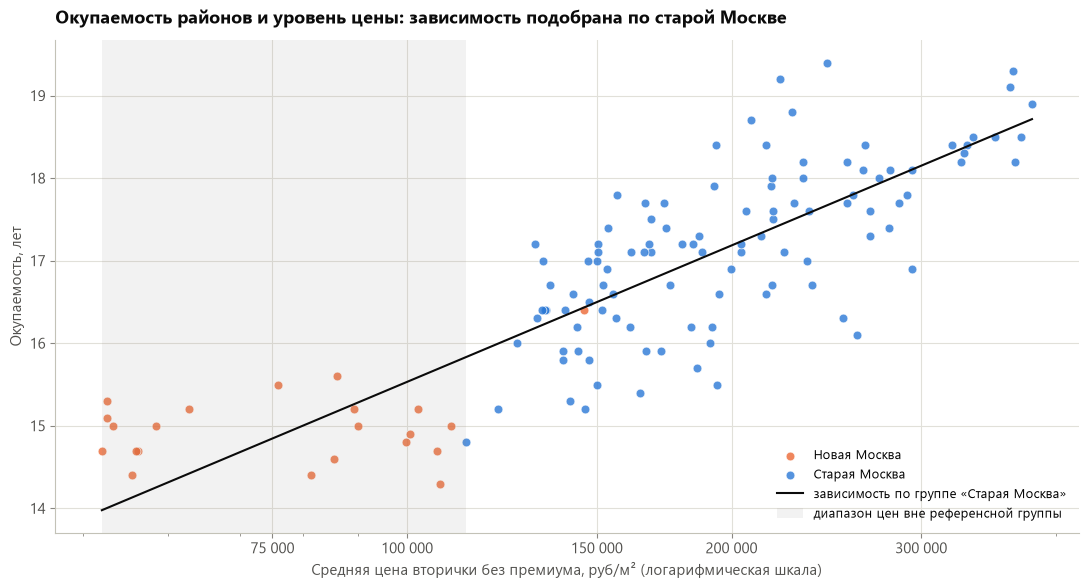

In [64]:
print('Спирмен, цена вторички ↔ окупаемость:')
for part, group in districts.groupby('moscow_part'):
    print(f"  {part}: {group['avg_price_sqm_no_premium'].corr(group['payback_years'], method='spearman'):.3f}")

print()
print(gradient_check(districts, 'avg_price_sqm_no_premium', 'payback_years', 'moscow_part', 'Старая Москва').to_string())

plot_price_gradient(
    districts, 'avg_price_sqm_no_premium', 'payback_years', 'moscow_part', 'Старая Москва',
    'Окупаемость районов и уровень цены: зависимость подобрана по старой Москве',
    'Окупаемость, лет',
)

**Две контрольные проверки механизма.** Совпадение среднего уровня — необходимое условие, но не достаточное. Если окупаемость определяется ценой, то:

1. районы Новой Москвы и старой Москвы **при одинаковой цене** должны окупаться одинаково
2. **внутри самой Новой Москвы** более дорогие районы должны окупаться дольше — так же, как внутри округов старой Москвы

In [65]:
old_min = districts.loc[districts['is_new_moscow'] == 0, 'avg_price_sqm_no_premium'].min()
new_max = districts.loc[districts['is_new_moscow'] == 1, 'avg_price_sqm_no_premium'].max()
overlap = districts[districts['avg_price_sqm_no_premium'].between(old_min, new_max)]
print(f'=== 1. Общий диапазон цен двух частей: {old_min:,.0f} — {new_max:,.0f} руб/м² ===')
print(overlap.groupby('moscow_part').agg(
    районов=('district', 'size'),
    цена=('avg_price_sqm_no_premium', 'median'),
    окупаемость=('payback_years', 'median'),
).to_string())

print('\n=== 2. Связь цены и окупаемости внутри округов (Спирмен) ===')
okrug_corr = districts.groupby(['moscow_part', 'okrug']).apply(
    lambda g: pd.Series({
        'районов': len(g),
        'цена, медиана': g['avg_price_sqm_no_premium'].median(),
        'окупаемость, медиана': g['payback_years'].median(),
        'Спирмен': round(g['avg_price_sqm_no_premium'].corr(g['payback_years'], method='spearman'), 2)
                   if len(g) > 2 else None,
    }),
    include_groups=False,
)
print(okrug_corr.to_string())

=== 1. Общий диапазон цен двух частей: 113,362 — 146,034 руб/м² ===
               районов      цена  окупаемость
moscow_part                                  
Новая Москва         1  146034.0         16.4
Старая Москва       17  134607.0         16.3

=== 2. Связь цены и окупаемости внутри округов (Спирмен) ===
                     районов  цена, медиана  окупаемость, медиана  Спирмен
moscow_part   okrug                                                       
Новая Москва  NAO       11.0       100724.0                 14.90     0.30
              TAO       10.0        55786.0                 15.00     0.26
              ZelAO      1.0        89312.0                 15.20      NaN
Старая Москва CAO       10.0       356805.0                 18.50     0.44
              SAO       15.0       175221.0                 17.20     0.92
              SVAO      17.0       156246.0                 16.90     0.81
              SZAO       9.0       199966.0                 16.90     0.45
           

### Выводы по 8.8.1

**Различие настоящее и устойчивое.** Районы Новой Москвы окупаются быстрее: медиана 15.0 года против 17.2, размер эффекта 0.953 — распределения почти не пересекаются. Разрыв держится в каждом году с 2021 по 2026 (от 1.6 до 2.6 года) и внутри каждой группы жилья:

| Разрез | Разница, лет |
|---|---|
| Тип дома (6 типов) | от −1.6 (хрущёвка) до −2.5 (совр. панель) |
| Число комнат (1–4) | от −1.8 до −2.3 |
| Ремонт (4 вида) | от −1.8 до −3.3 |

**Состав жилья различие не объясняет.** Доли типов домов в двух частях города почти одинаковые — расхождение меньше процентного пункта по каждому типу. А разрыв при этом сохраняется внутри каждого типа отдельно.

**Разрыв сокращается.** В 2021–2023 он составлял 2.4–2.6 года, в 2024–2026 — 1.6–1.9. Причина видна по росту медиан с 2021 года: в Новой Москве вторичка подорожала на 28.0%, а аренда — только на 21.2%, то есть покупка там дорожала быстрее, чем росла отдача от сдачи. В старой Москве обе величины выросли одинаково, примерно на 24%.

**Механизм подтвердился только наполовину.** Гипотеза «дешевле — значит быстрее окупается» объясняет **уровень**:

- зависимость, подобранная только по старой Москве, для цен Новой Москвы предсказывает 15.1 года, фактически — 15.0
- единственный район Новой Москвы, который по цене попадает в диапазон старой (Мосрентген, 146 тыс. руб/м²), окупается за 16.4 года — так же, как 17 районов старой Москвы той же цены (16.3)

Но **структуру внутри Новой Москвы** она не объясняет. ТАО почти вдвое дешевле НАО (медианы 55.8 и 100.7 тыс. руб/м²), и по зависимости старой Москвы разница в окупаемости между ними должна была бы составить около 1.4 года (14.1 против 15.5). Фактически они окупаются одинаково — 15.0 и 14.9. Внутри округов Новой Москвы связь цены и окупаемости слабая (Спирмен 0.26–0.30), тогда как в большинстве округов старой Москвы она сильная (0.67–0.94).

**Итог.** Сам факт — Новая Москва окупается примерно на 2 года быстрее — надёжен. Объяснение «потому что она дешевле» согласуется с данными на уровне частей города, но внутри Новой Москвы соотношение аренды и цены почти не зависит от цены района. Датасет полусинтетический, и такая картина похожа на то, что генератор задаёт это соотношение для Новой Москвы отдельно; различить «экономику» и «устройство генератора» на этих данных нельзя. Поэтому в дашборде это различие стоит показывать как факт, без утверждения о его причине.

### 8.8.2 Наценка новостроек

Те же проверки для наценки новостроек над вторичкой в том же районе. Дополнительно сравниваем наценку не только в процентах, но и в рублях за м²: процент зависит от базы, от которой он считается.

In [66]:
with_new_builds = districts.dropna(subset=['newbuild_premium_pct']).copy()
with_new_builds['Наценка, руб/м²'] = (with_new_builds['avg_newbuild_sqm_no_premium']
                                      - with_new_builds['avg_price_sqm_no_premium'])

print(with_new_builds.groupby('moscow_part').agg(
    районов=('district', 'size'),
    вторичка=('avg_price_sqm_no_premium', 'median'),
    новостройки=('avg_newbuild_sqm_no_premium', 'median'),
    наценка_руб=('Наценка, руб/м²', 'median'),
    наценка_pct=('newbuild_premium_pct', 'median'),
    мин_pct=('newbuild_premium_pct', 'min'),
    макс_pct=('newbuild_premium_pct', 'max'),
).round(1).to_string())

df_new_builds['year'] = pd.to_datetime(df_new_builds['date_posted']).dt.year
sec_year = df_secondary[~df_secondary['is_premium']].groupby(['year', 'is_new_moscow'])['price_per_sqm'].median()
new_year = df_new_builds[~df_new_builds['is_premium']].groupby(['year', 'is_new_moscow'])['price_per_sqm'].median()
premium_by_year = ((new_year / sec_year - 1) * 100).round(1).unstack('is_new_moscow').rename(columns=PART_NAMES).dropna()
print('\n=== Наценка новостроек по годам, % (медианы объявлений) ===')
print(premium_by_year.to_string())

               районов  вторичка  новостройки  наценка_руб  наценка_pct  мин_pct  макс_pct
moscow_part                                                                               
Новая Москва        20   83732.0     122433.0      34379.5         49.6     22.5     147.3
Старая Москва       89  191019.0     258205.0      58544.0         34.0    -10.4     119.7

=== Наценка новостроек по годам, % (медианы объявлений) ===
is_new_moscow  Старая Москва  Новая Москва
year                                      
2021                    36.0          52.0
2022                    30.8          60.9
2023                    34.6          44.4
2024                    31.8          39.7
2025                    33.2          46.3
2026                    30.5          40.7


Спирмен, цена вторички ↔ наценка новостроек:
  Новая Москва: -0.024
  Старая Москва: -0.322

                n  median_price  median_actual  median_expected  mean_residual
moscow_part                                                                   
Новая Москва   20       83732.0           49.6             56.2            5.7
Старая Москва  89      191019.0           34.0             37.6            0.0


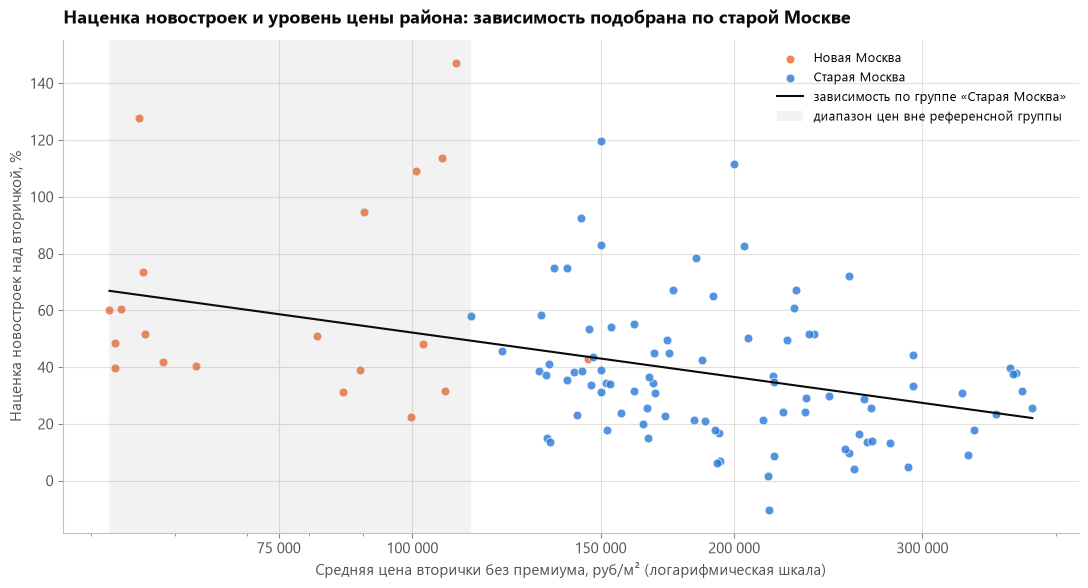

In [67]:
print('Спирмен, цена вторички ↔ наценка новостроек:')
for part, group in with_new_builds.groupby('moscow_part'):
    print(f"  {part}: {group['avg_price_sqm_no_premium'].corr(group['newbuild_premium_pct'], method='spearman'):.3f}")

print()
print(gradient_check(with_new_builds, 'avg_price_sqm_no_premium', 'newbuild_premium_pct', 'moscow_part', 'Старая Москва').to_string())

plot_price_gradient(
    with_new_builds, 'avg_price_sqm_no_premium', 'newbuild_premium_pct', 'moscow_part', 'Старая Москва',
    'Наценка новостроек и уровень цены района: зависимость подобрана по старой Москве',
    'Наценка новостроек над вторичкой, %',
)

### Выводы по 8.8.2

**Различие в процентах тоже устойчивое.** Медиана наценки по районам — 49.6% в Новой Москве против 34.0% в старой, размер эффекта 0.510 (большой), p = 0.0004. В каждом году с 2021 по 2026 наценка в Новой Москве выше — на величину от 7.9 до 30.1 процентного пункта.

**Но в рублях картина обратная.** Новостройка в Новой Москве дороже вторички в том же районе на 34.4 тыс. руб/м², а в старой — на 58.5 тыс. Процент выше только потому, что база в 2.3 раза ниже (вторичка 83.7 тыс. против 191.0 тыс. руб/м²). Одинаковая по смыслу надбавка за новое жильё на дешёвой базе выглядит большим процентом.

**Уровень цены это объясняет — даже с запасом.** Уже внутри старой Москвы чем дешевле район, тем выше наценка в процентах (Спирмен −0.32). Если продлить эту зависимость на цены Новой Москвы, она предсказывает 56.2% — фактическая медиана 49.6% даже ниже ожидаемого (медианный остаток −6.3 п.п.). Средний остаток при этом положительный (+5.7 п.п.) из-за трёх районов с наценкой 114–147%: Внуковское, Михайлово-Ярцевское и Сосенское. Это не ошибка малой выборки — в них от 30 до 67 объявлений новостроек, — а просто сильный разброс, который есть и в старой Москве (от −10% до +120%).

Внутри самой Новой Москвы связи с ценой нет (Спирмен −0.02) — та же оговорка, что и в 8.8.1.

Правдоподобное экономическое объяснение: у цены новостройки есть нижняя граница — себестоимость строительства почти не зависит от района, поэтому в дешёвых районах новое жильё отрывается от вторички сильнее в процентах, хотя и слабее в рублях. Проверить это на данных без себестоимости нельзя, поэтому это интерпретация, а не вывод.

**Итог для дашборда:** наценку новостроек нужно показывать и в процентах, и в рублях за м². Один процент без рублей создаёт ложное впечатление, что новое жильё в Новой Москве «переплачивается» сильнее, чем в старой.